#TFC

## Construção da Base de Dados

In [1]:
import pandas as pd
import numpy as np

In [2]:
FILE_PATH = "Relatorio_dados_Indicadores_2023_limpo.xlsx"
TIPOS_SISTEMA = ["Baixa", "Alta"]
RAMO_AA = "AA"

# =========================
# 1) WHITELISTS (CÓDIGOS)
# =========================
IND_CODES = [
    "AA02b","AA01b","AA14b","AA07b","AA06a","AA06b",
    "PAA01b","AA16a","AA16b",
    "AA10a","AA10b","AA03a","AA03b","AA15a","AA15b",
    "PAA12b","AA09a","AA09b","AA05a","AA05b",
    "PAA11a","PAA11b",
    "AA08a","AA08b",
    "PAA04a","PAA04b"
]

VAR_CODES = [
    "dAA020b","dAA019b","dAA021b","dAA043a","dAA043b","dAA027a","dAA027b",
    "dAA026a","dAA026b","dAA028a","dAA028b","dAA051a","dAA051b","dAA075a","dAA075b",
    "dAA072a","dAA072b","dAA052a","dAA052b","dAA053a","dAA053b","dAA054a","dAA054b",
    "dAA055a","dAA055b","dAA040a","dAA040b","dAA104b","dAA105b","dAA041a","dAA041b",
    "dAA073a","dAA073b","dAA103a","dAA103b","dAA001a","dAA001b",
    "dAA101a","dAA101b","dAA061a","dAA061b","dAA062a","dAA062b","dAA017b","dAA018b",
    "dAA042b","dAA029b","dAA100a","dAA100b","dAA102a","dAA102b","dAA025a","dAA025b",
    "dAA056a","dAA056b","dAA039a","dAA039b","dAA069a","dAA069b","dAA070a","dAA070b",
    "dAA068a","dAA068b","dAA064a","dAA064b","dAA048a","dAA048b","dAA057a","dAA057b",
    "dAA058b","dAA059b","dAA060a","dAA060b","dAA067a","dAA067b","dAA049a","dAA049b",
    "dAA009a","dAA009b","dAA010a","dAA010b","dAA011a","dAA011b","dAA002b","dAA002a",
    "dAA012b","dAA012a"
]

# =========================
# 2) FUNÇÕES AUXILIARES
# =========================
def detect_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"Não encontrei nenhuma destas colunas: {candidates}")

def get_ramo_col(df):
    if "RamoAtividade" in df.columns:
        return "RamoAtividade"
    if "Ramo Atividade" in df.columns:
        return "Ramo Atividade"
    raise KeyError("Não encontrei coluna de ramo de atividade.")

def make_wide(df, index_cols, name_col, code_col, value_col):
    df = df.copy()
    df["Nome_Coluna"] = (
        df[name_col].astype(str).str.strip()
        + " (" + df[code_col].astype(str).str.strip() + ")"
    )

    wide = df.pivot_table(
        index=index_cols,
        columns="Nome_Coluna",
        values=value_col,
        aggfunc="first"
    ).reset_index()

    fixed = index_cols
    others = sorted([c for c in wide.columns if c not in fixed])
    return wide[fixed + others]

# =========================
# 3) INDICADORES
# =========================
df_ind = pd.read_excel(
    FILE_PATH,
    sheet_name="Indicadores_2023",
    keep_default_na=False   # 🔴 IMPORTANTE
)

df_ind.columns = df_ind.columns.str.strip()

ramo_col_ind = get_ramo_col(df_ind)
tipo_col = detect_col(df_ind, ["Tipo Sistema"])
name_col_ind = detect_col(df_ind, ["Indicador"])
code_col_ind = detect_col(df_ind, ["Codigo Indicador", "Código Indicador"])

df_ind = df_ind[
    (df_ind[ramo_col_ind] == RAMO_AA) &
    (df_ind[tipo_col].isin(TIPOS_SISTEMA)) &
    (df_ind[code_col_ind].isin(IND_CODES))
]

indicadores_wide = make_wide(
    df_ind,
    index_cols=["Empresa", tipo_col],
    name_col=name_col_ind,
    code_col=code_col_ind,
    value_col="Valor"
)

# =========================
# 4) VARIÁVEIS
# =========================
df_var = pd.read_excel(
    FILE_PATH,
    sheet_name="Dados_2023",
    keep_default_na=False   # 🔴 IMPORTANTE
)

df_var.columns = df_var.columns.str.strip()

ramo_col_var = get_ramo_col(df_var)
name_col_var = detect_col(df_var, ["Variavel", "Variável"])
code_col_var = detect_col(df_var, ["Codigo Variavel", "Código Variavel"])

df_var = df_var[
    (df_var[ramo_col_var] == RAMO_AA) &
    (df_var[tipo_col].isin(TIPOS_SISTEMA)) &
    (df_var[code_col_var].isin(VAR_CODES))
]

variaveis_wide = make_wide(
    df_var,
    index_cols=["Empresa", tipo_col],
    name_col=name_col_var,
    code_col=code_col_var,
    value_col="Valor"
)

# =========================
# 5) MERGE FINAL
# =========================
indicadores_wide = indicadores_wide.set_index(["Empresa", tipo_col])

base_completa = variaveis_wide.merge(
    indicadores_wide,
    on=["Empresa", tipo_col],
    how="outer"
)

# =========================
# 6) BASE BAIXA / ALTA
# =========================
id_cols = ["Empresa", tipo_col]

base_baixa = base_completa[
    base_completa[tipo_col] == "Baixa"
][id_cols + [c for c in base_completa.columns if c.endswith("b)")]].copy()

base_alta = base_completa[
    base_completa[tipo_col] == "Alta"
][id_cols + [c for c in base_completa.columns if c.endswith("a)")]].copy()

display(base_completa)


Nome_Coluna,Empresa,Tipo Sistema,Alojamentos com serviço disponível não efetivo (dAA020b),Alojamentos com serviço efetivo (dAA019b),Alojamentos existentes (dAA021b),Avarias em condutas (dAA043a),Avarias em condutas (dAA043b),Comprimento médio de condutas com mais de 10 anos (dAA027a),Comprimento médio de condutas com mais de 10 anos (dAA027b),Comprimento total de condutas (dAA026a),...,Reabilitação de condutas (AA09a),Reabilitação de condutas (AA09b),"Resposta a reclamações, sugestões e pedidos de informação escritos (AA05a)","Resposta a reclamações, sugestões e pedidos de informação escritos (AA05b)","Resposta a reclamações, sugestões e pedidos de informação telefónicos (PAA11a)","Resposta a reclamações, sugestões e pedidos de informação telefónicos (PAA11b)",Água não faturada (AA08a),Água não faturada (AA08b),Índice de valor da infraestrutura (PAA04a),Índice de valor da infraestrutura (PAA04b)
0,AGERE,Baixa,6796,81302,88412,NaN,242,NaN,1100.9,NaN,...,NaN,0.3,NaN,100,NaN,100,NaN,13.7,NaN,0.48
1,AMBIOLHÃO,Baixa,2407,22750,27196,NaN,384,NaN,338.2,NaN,...,NaN,0.4,NaN,87,NaN,NR,NaN,19.6,NaN,NR
2,APIN,Baixa,2701,60921,63656,NaN,1582,NaN,2308,NaN,...,NaN,1.3,NaN,100,NaN,100,NaN,55.1,NaN,0.15
3,Aquaelvas,Baixa,885,10683,13488,NaN,151,NaN,236.7,NaN,...,NaN,0.1,NaN,100,NaN,NA,NaN,38.8,NaN,0.28
4,Aquafundalia,Baixa,NR,17089,22326,NaN,227,NaN,434.7,NaN,...,NaN,0,NaN,100,NaN,NR,NaN,35.5,NaN,NR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223,Águas do Planalto,Baixa,10905,32077,46196,NaN,706,NaN,1638.8,NaN,...,NaN,0.6,NaN,100,NaN,100,NaN,16.5,NaN,0.36
224,Águas do Ribatejo,Baixa,8781,70082,82178,NaN,600,NaN,1555.2,NaN,...,NaN,0.5,NaN,99,NaN,NR,NaN,30.8,NaN,0.4
225,Águas do Vale do Tejo,Alta,NaN,NaN,NaN,216,NaN,3297.6,NaN,3610.1,...,0.4,NaN,100,NaN,NA,NaN,6.7,NaN,NR,NaN
226,Águas do Vouga,Alta,NaN,NaN,NaN,7,NaN,106.1,NaN,218.7,...,0,NaN,100,NaN,NA,NaN,2.4,NaN,0.66,NaN


In [3]:
print("Base Baixa:", base_baixa.shape)


Base Baixa: (218, 67)


In [4]:

print("Base Alta :", base_alta.shape)


Base Alta : (10, 50)


 ## Limpeza e organizaçoa dos dados

###Base_Baixa

#### Identificação de valores textuais em colunas de natureza quantitativa

In [5]:
colunas_categoricas = ["Empresa", "Tipo Sistema"] + [
    col for col in base_baixa.columns
    if any(cod in col for cod in ["dAA001b", "dAA002b", "dAA025b"])
]

colunas_quantitativas = [col for col in base_baixa.columns
                         if col not in colunas_categoricas]

In [6]:
def encontrar_strings_inesperadas(df, colunas_excluir):

    registos = []

    for col in df.columns:
        if col in colunas_excluir:
            continue

        s = df[col].astype(str).str.strip()
        convertida = pd.to_numeric(s, errors="coerce")

        mask_nao_numerico = convertida.isna()
        mask_nao_nan = s != "nan"

        valores_estranhos = s[mask_nao_numerico & mask_nao_nan].unique().tolist()

        for valor in valores_estranhos:
            registos.append({"coluna": col, "valor_inesperado": valor})

    return pd.DataFrame(registos)

resultado_strings = encontrar_strings_inesperadas(base_baixa, colunas_categoricas)
print(resultado_strings["valor_inesperado"].unique())

['NR' 'NA']


In [7]:
valores = ["NA", "NR"]

# colunas de dados (exclui Empresa e Tipo Sistema)
cols_dados = [
    c for c in base_baixa.columns
    if c not in ["Empresa", tipo_col]
]

# normalizar para string e remover espaços
dados_baixa = base_baixa[cols_dados].apply(
    lambda col: col.astype(str).str.strip()
)

# contagem total de cada valor
contagem = {
    v: (dados_baixa == v).sum().sum()
    for v in valores
}

pd.Series(contagem, name="N.º de ocorrências")

,N.º de ocorrências
NA,508
NR,1137


In [8]:
import pandas as pd

def encontrar_valores_negativos(df, colunas_quantitativas):
    registos = []

    for col in colunas_quantitativas:

        serie = pd.to_numeric(df[col].astype(str).str.strip(), errors="coerce")
        negativos = serie[serie < 0]

        for idx, valor in negativos.items():
            registos.append({
                "coluna": col,
                "indice": idx,
                "valor_negativo": valor
            })

    return pd.DataFrame(registos)


resultado_negativos = encontrar_valores_negativos(base_baixa, colunas_quantitativas)
resultado_negativos

""


In [9]:
# duplicados completos
duplicados_linhas = base_baixa[base_baixa.duplicated()]

print("Número de linhas totalmente duplicadas:", duplicados_linhas.shape[0])

duplicados_linhas

Número de linhas totalmente duplicadas: 0


Nome_Coluna,Empresa,Tipo Sistema,Alojamentos com serviço disponível não efetivo (dAA020b),Alojamentos com serviço efetivo (dAA019b),Alojamentos existentes (dAA021b),Avarias em condutas (dAA043b),Comprimento médio de condutas com mais de 10 anos (dAA027b),Comprimento total de condutas (dAA026b),Condutas reabilitadas nos últimos cinco anos (dAA028b),Consumo autorizado (dAA051b),...,Eficiência energética de instalações elevatórias (AA16b),Ocorrência de avarias em condutas (AA10b),Ocorrência de falhas no abastecimento (AA03b),Perdas reais de água (AA15b),Ramais afetados por falhas no abastecimento (PAA12b),Reabilitação de condutas (AA09b),"Resposta a reclamações, sugestões e pedidos de informação escritos (AA05b)","Resposta a reclamações, sugestões e pedidos de informação telefónicos (PAA11b)",Água não faturada (AA08b),Índice de valor da infraestrutura (PAA04b)


In [10]:
# duplicados por empresa
duplicados_empresa = base_baixa[
    base_baixa.duplicated(subset=["Empresa"], keep=False)
].sort_values("Empresa")

print("Número de empresas repetidas:", duplicados_empresa["Empresa"].nunique())

duplicados_empresa

Número de empresas repetidas: 0


Nome_Coluna,Empresa,Tipo Sistema,Alojamentos com serviço disponível não efetivo (dAA020b),Alojamentos com serviço efetivo (dAA019b),Alojamentos existentes (dAA021b),Avarias em condutas (dAA043b),Comprimento médio de condutas com mais de 10 anos (dAA027b),Comprimento total de condutas (dAA026b),Condutas reabilitadas nos últimos cinco anos (dAA028b),Consumo autorizado (dAA051b),...,Eficiência energética de instalações elevatórias (AA16b),Ocorrência de avarias em condutas (AA10b),Ocorrência de falhas no abastecimento (AA03b),Perdas reais de água (AA15b),Ramais afetados por falhas no abastecimento (PAA12b),Reabilitação de condutas (AA09b),"Resposta a reclamações, sugestões e pedidos de informação escritos (AA05b)","Resposta a reclamações, sugestões e pedidos de informação telefónicos (PAA11b)",Água não faturada (AA08b),Índice de valor da infraestrutura (PAA04b)


In [11]:
contagem_empresas = base_baixa["Empresa"].value_counts()

empresas_repetidas = contagem_empresas[contagem_empresas > 1]

empresas_repetidas

,count
Empresa,


#### Tratamentos dos NA e NR

##### Tratar dos NA

In [12]:
colunas_com_NA = base_baixa.columns[
    (base_baixa == "NA").any()
]

In [13]:
valores = ["NA", "NR"]

# colunas de dados (exclui Empresa e Tipo Sistema)
cols_dados = [
    c for c in base_baixa.columns
    if c not in ["Empresa", tipo_col]
]

# normalizar para string e remover espaços
dados_baixa = base_baixa[cols_dados].apply(
    lambda col: col.astype(str).str.strip()
)

# contagem total de cada valor
contagem = {
    v: (dados_baixa == v).sum().sum()
    for v in valores
}

pd.Series(contagem, name="N.º de ocorrências")

,N.º de ocorrências
NA,508
NR,1137


In [14]:
base_baixa.shape

(218, 67)

In [15]:
def tabela_missing_tokens(df):

    resultados = []

    for col in df.columns:

        # ignorar identificadores
        if col in ["Empresa", "Tipo Sistema"]:
            continue

        s = df[col].astype(str).str.strip()

        n_na = (s == "NA").sum()
        n_nr = (s == "NR").sum()
        total = n_na + n_nr
        pct = total / len(df) * 100

        resultados.append({
            "Coluna": col,
            "NA": n_na,
            "NR": n_nr,
            "NA+NR": total,
            "% NA+NR": pct
        })

    tabela = (
        pd.DataFrame(resultados)
        .sort_values("NA+NR", ascending=False)
        .reset_index(drop=True)
    )

    return tabela

In [16]:
missing_resumo = tabela_missing_tokens(base_baixa)
display(missing_resumo.head(60))

,Coluna,NA,NR,NA+NR,% NA+NR
0,Volume de água medido nos 3 meses com menores ...,175,10,185,84.862385
1,Volume de água medido nos 3 meses com maiores ...,175,10,185,84.862385
2,"Resposta a reclamações, sugestões e pedidos de...",39,104,143,65.596330
3,Eficiência energética de instalações elevatóri...,27,73,100,45.871560
4,Fator de uniformização (dAA073b),26,68,94,43.119266
5,Valor atual da rede (dAA039b),0,70,70,32.110092
6,Custo de substituição (dAA040b),0,70,70,32.110092
7,Índice de valor da infraestrutura (PAA04b),0,68,68,31.192661
8,Consumo de energia para bombeamento (dAA072b),1,66,67,30.733945
9,Ramais afetados por falhas no abastecimento (P...,0,59,59,27.064220


In [17]:
colunas_com_NA.tolist()

['Consumo de energia para bombeamento (dAA072b)',
 'Encargo anual com tarifário social (dAA105b)',
 'Fator de uniformização (dAA073b)',
 'Volume de água medido nos 3 meses com maiores volumes (dAA069b)',
 'Volume de água medido nos 3 meses com menores volumes (dAA070b)',
 'Eficiência energética de instalações elevatórias (AA16b)',
 'Resposta a reclamações, sugestões e pedidos de informação escritos (AA05b)',
 'Resposta a reclamações, sugestões e pedidos de informação telefónicos (PAA11b)']

In [18]:
base_baixa = base_baixa.drop(columns=colunas_com_NA)

print(f"Foram removidas {len(colunas_com_NA)} colunas.")

Foram removidas 8 colunas.


In [19]:
print("Base Baixa:", base_baixa.shape)


Base Baixa: (218, 59)


##### Tratar dos RN

In [20]:
valores = ["ND", "NA", "NR"]

# colunas de dados (exclui Empresa e Tipo Sistema)
cols_dados = [
    c for c in base_baixa.columns
    if c not in ["Empresa", tipo_col]
]

# normalizar para string e remover espaços
dados_baixa = base_baixa[cols_dados].apply(
    lambda col: col.astype(str).str.strip()
)

# contagem total de cada valor
contagem = {
    v: (dados_baixa == v).sum().sum()
    for v in valores
}

pd.Series(contagem, name="N.º de ocorrências")

,N.º de ocorrências
ND,0
NA,0
NR,782


In [21]:
missing_resumo = tabela_missing_tokens(base_baixa)

display(missing_resumo.head(60))

,Coluna,NA,NR,NA+NR,% NA+NR
0,Custo de substituição (dAA040b),0,70,70,32.110092
1,Valor atual da rede (dAA039b),0,70,70,32.110092
2,Índice de valor da infraestrutura (PAA04b),0,68,68,31.192661
3,Ramais afetados por falhas no abastecimento (P...,0,59,59,27.064220
4,Ramais afetados por falhas no abastecimento (d...,0,56,56,25.688073
5,Água captada (dAA064b),0,41,41,18.807339
6,Consumo de energia (dAA075b),0,40,40,18.348624
7,Ocorrência de falhas no abastecimento (AA03b),0,26,26,11.926606
8,Falhas no abastecimento (dAA041b),0,22,22,10.091743
9,Perdas reais de água (AA15b),0,22,22,10.091743


In [22]:
percent_nr = (base_baixa == "NR").mean() * 100

In [23]:
colunas_remover = percent_nr[percent_nr > 25].index.tolist()

colunas_remover

['Custo de substituição (dAA040b)',
 'Ramais afetados por falhas no abastecimento (dAA042b)',
 'Valor atual da rede (dAA039b)',
 'Ramais afetados por falhas no abastecimento (PAA12b)',
 'Índice de valor da infraestrutura (PAA04b)']

In [24]:
base_baixa = base_baixa.drop(columns=colunas_remover)

print(f"Foram removidas {len(colunas_remover)} colunas com NR > 25%.")

Foram removidas 5 colunas com NR > 25%.


In [25]:
valores = ["ND", "NA", "NR"]

# colunas de dados (exclui Empresa e Tipo Sistema)
cols_dados = [
    c for c in base_baixa.columns
    if c not in ["Empresa", tipo_col]
]

# normalizar para string e remover espaços
dados_baixa = base_baixa[cols_dados].apply(
    lambda col: col.astype(str).str.strip()
)

# contagem total de cada valor
contagem = {
    v: (dados_baixa == v).sum().sum()
    for v in valores
}

pd.Series(contagem, name="N.º de ocorrências")

,N.º de ocorrências
ND,0
NA,0
NR,459


In [26]:
missing_resumo = tabela_missing_tokens(base_baixa)

display(missing_resumo.head(60))

,Coluna,NA,NR,NA+NR,% NA+NR
0,Água captada (dAA064b),0,41,41,18.807339
1,Consumo de energia (dAA075b),0,40,40,18.348624
2,Ocorrência de falhas no abastecimento (AA03b),0,26,26,11.926606
3,Falhas no abastecimento (dAA041b),0,22,22,10.091743
4,Perdas reais de água (AA15b),0,22,22,10.091743
5,Rendimentos tarifários (dAA100b),0,17,17,7.798165
6,Água não faturada (AA08b),0,17,17,7.798165
7,Água não faturada (dAA060b),0,17,17,7.798165
8,Perdas reais (dAA062b),0,17,17,7.798165
9,Subsídios ao investimento (dAA102b),0,17,17,7.798165


Transformar os NR em missing values

In [27]:
def tratar_nr_para_float(df, colunas_excluir):
    df = df.copy()

    # Selecionar colunas a tratar
    colunas_tratar = [col for col in df.columns if col not in colunas_excluir]

    for col in colunas_tratar:
        if df[col].dtype == "object":
            # Substituir NR por missing real
            df[col] = df[col].replace("NR", pd.NA)

            # Converter para float
            df[col] = pd.to_numeric(df[col], errors="coerce").astype(float)

    return df

In [28]:
base_baixa = tratar_nr_para_float(base_baixa, colunas_categoricas)

In [29]:
missing_resumo = tabela_missing_tokens(base_baixa)

display(missing_resumo.head(60))

,Coluna,NA,NR,NA+NR,% NA+NR
0,Alojamentos com serviço disponível não efetivo...,0,0,0,0.0
1,Alojamentos com serviço efetivo (dAA019b),0,0,0,0.0
2,Alojamentos existentes (dAA021b),0,0,0,0.0
3,Avarias em condutas (dAA043b),0,0,0,0.0
4,Comprimento médio de condutas com mais de 10 a...,0,0,0,0.0
5,Comprimento total de condutas (dAA026b),0,0,0,0.0
6,Condutas reabilitadas nos últimos cinco anos (...,0,0,0,0.0
7,Consumo autorizado (dAA051b),0,0,0,0.0
8,Consumo de energia (dAA075b),0,0,0,0.0
9,Consumo faturado medido (dAA052b),0,0,0,0.0


In [30]:
base_baixa.info()

<class 'pandas.core.frame.DataFrame'>
Index: 218 entries, 0 to 227
Data columns (total 54 columns):
 #   Column                                                                          Non-Null Count  Dtype  
---  ------                                                                          --------------  -----  
 0   Empresa                                                                         218 non-null    object 
 1   Tipo Sistema                                                                    218 non-null    object 
 2   Alojamentos com serviço disponível não efetivo (dAA020b)                        211 non-null    float64
 3   Alojamentos com serviço efetivo (dAA019b)                                       215 non-null    float64
 4   Alojamentos existentes (dAA021b)                                                218 non-null    float64
 5   Avarias em condutas (dAA043b)                                                   206 non-null    float64
 6   Comprimento médio de co

In [31]:
print("Base Baixa:", base_baixa.shape)

Base Baixa: (218, 54)


#### Ver a percentagem de missing values

##### Ver a percentagem de missing values por coluna

In [32]:
base_baixa.shape

(218, 54)

In [33]:
colunas_float = base_baixa.select_dtypes(include=["float64"]).columns

In [34]:
colunas_float = base_baixa.select_dtypes(include=["float64"]).columns

total_empresas = len(base_baixa)

resumo_missing = pd.DataFrame({
    "Missing (nº empresas)": base_baixa[colunas_float].isna().sum(),
    "Percentagem Missing (%)": base_baixa[colunas_float].isna().mean() * 100,
    "Valores Válidos (nº empresas)": base_baixa[colunas_float].notna().sum(),
    "Total Empresas": total_empresas
}).sort_values("Percentagem Missing (%)", ascending=False)

resumo_missing.round(2)


,Missing (nº empresas),Percentagem Missing (%),Valores Válidos (nº empresas),Total Empresas
Nome_Coluna,,,,
Água captada (dAA064b),41,18.81,177,218
Consumo de energia (dAA075b),40,18.35,178,218
Ocorrência de falhas no abastecimento (AA03b),26,11.93,192,218
Falhas no abastecimento (dAA041b),22,10.09,196,218
Perdas reais de água (AA15b),22,10.09,196,218
Perdas reais (dAA062b),17,7.80,201,218
Gastos totais (dAA103b),17,7.80,201,218
Outros rendimentos (dAA101b),17,7.80,201,218
Água não faturada (dAA060b),17,7.80,201,218


##### Ver a percentagem de missing values por empresa

In [35]:
def encontrar_coluna_por_codigo(df, codigo):
    cols = [c for c in df.columns if f"({codigo})" in c]

    if len(cols) == 0:
        raise ValueError(f"Não encontrei coluna com código {codigo}")

    if len(cols) > 1:
        raise ValueError(f"Mais de uma coluna encontrada para {codigo}")

    return cols[0]

In [36]:
# =========================
# MISSING — POR EMPRESA
# =========================

# Selecionar apenas colunas numéricas
colunas_float = base_baixa.select_dtypes(include=["float64"]).columns

total_variaveis = len(colunas_float)

# Calcular missing por empresa
missing_por_empresa = pd.DataFrame({
    "Empresa": base_baixa["Empresa"],
    "Nº Colunas em Falta": base_baixa[colunas_float].isna().sum(axis=1),
})

missing_por_empresa["Percentagem Missing (%)"] = (
    missing_por_empresa["Nº Colunas em Falta"] / total_variaveis * 100
)

missing_por_empresa["Total Variáveis"] = total_variaveis

# Ordenar pelas piores empresas
missing_por_empresa = missing_por_empresa.sort_values(
    "Percentagem Missing (%)", ascending=False
)

missing_por_empresa.round(2).head(60)


,Empresa,Nº Colunas em Falta,Percentagem Missing (%),Total Variáveis
49,CM de Estremoz,35,71.43,49
37,CM de Caminha,32,65.31,49
57,CM de Idanha-a-Nova,23,46.94,49
95,CM de Penedono,21,42.86,49
123,CM de Tabuaço,14,28.57,49
23,CM de Arganil,14,28.57,49
136,CM de Vila Nova de Paiva,13,26.53,49
27,CM de Avis,12,24.49,49
35,CM de Cabeceiras de Basto,12,24.49,49
84,CM de Mourão,11,22.45,49


In [37]:
col_anf = encontrar_coluna_por_codigo(base_baixa, "AA08b")
col_perdas = encontrar_coluna_por_codigo(base_baixa, "AA15b")

In [38]:
missing_total = base_baixa.isna().mean(axis=1) * 100

empresas_removidas = base_baixa[
    base_baixa[[col_anf, col_perdas]].isna().any(axis=1)
][["Empresa", col_anf, col_perdas]].copy()

empresas_removidas["Percentagem Missing Empresa (%)"] = missing_total.loc[empresas_removidas.index]

empresas_removidas

Nome_Coluna,Empresa,Água não faturada (AA08b),Perdas reais de água (AA15b),Percentagem Missing Empresa (%)
8,CM de Aguiar da Beira,59.3,NaN,12.962963
23,CM de Arganil,NaN,NaN,25.925926
27,CM de Avis,61.5,NaN,22.222222
30,CM de Belmonte,59.7,NaN,16.666667
34,CM de Bragança,NaN,NaN,11.111111
35,CM de Cabeceiras de Basto,NaN,NaN,22.222222
37,CM de Caminha,NaN,NaN,59.259259
39,CM de Castro Daire,NaN,NaN,16.666667
46,CM de Cuba,62.7,NaN,14.814815
49,CM de Estremoz,NaN,NaN,64.814815


In [39]:
missing_total = base_baixa.isna().mean(axis=1) * 100

col_anf = encontrar_coluna_por_codigo(base_baixa, "dAA060b")

empresas_sem_ambos = base_baixa[
    base_baixa[col_anf].isna() &
    base_baixa[col_perdas].isna()
][["Empresa", col_anf, col_perdas]].copy()

empresas_sem_ambos["Percentagem Missing Empresa (%)"] = missing_total.loc[empresas_sem_ambos.index]

empresas_sem_ambos

Nome_Coluna,Empresa,Água não faturada (dAA060b),Perdas reais de água (AA15b),Percentagem Missing Empresa (%)
23,CM de Arganil,NaN,NaN,25.925926
34,CM de Bragança,NaN,NaN,11.111111
35,CM de Cabeceiras de Basto,NaN,NaN,22.222222
37,CM de Caminha,NaN,NaN,59.259259
39,CM de Castro Daire,NaN,NaN,16.666667
49,CM de Estremoz,NaN,NaN,64.814815
57,CM de Idanha-a-Nova,NaN,NaN,42.592593
76,CM de Monchique,NaN,NaN,12.962963
78,CM de Monforte,NaN,NaN,11.111111
95,CM de Penedono,NaN,NaN,38.888889


In [40]:
empresas_nao_comum = base_baixa[
    base_baixa[col_anf].isna() ^ base_baixa[col_perdas].isna()
][["Empresa", col_anf, col_perdas]].copy()

empresas_nao_comum["Percentagem Missing Empresa (%)"] = missing_total.loc[empresas_nao_comum.index]

empresas_nao_comum

Nome_Coluna,Empresa,Água não faturada (dAA060b),Perdas reais de água (AA15b),Percentagem Missing Empresa (%)
8,CM de Aguiar da Beira,282339.0,NaN,12.962963
27,CM de Avis,278606.0,NaN,22.222222
30,CM de Belmonte,433170.0,NaN,16.666667
46,CM de Cuba,385527.0,NaN,14.814815
84,CM de Mourão,333042.0,NaN,20.370370


In [41]:
empresas_nao_comum = base_baixa[
    base_baixa[col_anf].isna() & ~base_baixa[col_perdas].isna()
][["Empresa", col_anf, col_perdas]].copy()

empresas_nao_comum["Percentagem Missing Empresa (%)"] = missing_total.loc[empresas_nao_comum.index]

empresas_nao_comum

Nome_Coluna,Empresa,Água não faturada (dAA060b),Perdas reais de água (AA15b),Percentagem Missing Empresa (%)


In [42]:
base_baixa = base_baixa.dropna(subset=[col_anf, col_perdas]).copy()

In [43]:
empresas_removidas = base_baixa[
    base_baixa[[col_anf, col_perdas]].isna().any(axis=1)
][["Empresa", col_anf, col_perdas]]

empresas_removidas

Nome_Coluna,Empresa,Água não faturada (dAA060b),Perdas reais de água (AA15b)


In [44]:
base_baixa.shape

(196, 54)

In [45]:
# =========================
# MISSING — POR EMPRESA
# =========================

# Selecionar apenas colunas numéricas
colunas_float = base_baixa.select_dtypes(include=["float64"]).columns

total_variaveis = len(colunas_float)

# Calcular missing por empresa
missing_por_empresa = pd.DataFrame({
    "Empresa": base_baixa["Empresa"],
    "Nº Colunas em Falta": base_baixa[colunas_float].isna().sum(axis=1),
})

missing_por_empresa["Percentagem Missing (%)"] = (
    missing_por_empresa["Nº Colunas em Falta"] / total_variaveis * 100
)

missing_por_empresa["Total Variáveis"] = total_variaveis

# Ordenar pelas piores empresas
missing_por_empresa = missing_por_empresa.sort_values(
    "Percentagem Missing (%)", ascending=False
)

missing_por_empresa.round(2).head(60)

,Empresa,Nº Colunas em Falta,Percentagem Missing (%),Total Variáveis
123,CM de Tabuaço,14,28.57,49
15,CM de Alijó,9,18.37,49
28,CM de Barrancos,8,16.33,49
13,CM de Alcácer do Sal,7,14.29,49
121,CM de São João da Pesqueira,6,12.24,49
36,CM de Cadaval,6,12.24,49
64,CM de Macedo de Cavaleiros,5,10.20,49
79,CM de Montalegre,5,10.20,49
18,CM de Almeida,5,10.20,49
38,CM de Castelo de Paiva,5,10.20,49


In [46]:
percent_missing = base_baixa.isna().mean(axis=1) * 100

base_baixa["percent_missing"] = percent_missing

base_baixa = base_baixa[base_baixa["percent_missing"] <= 20].copy()

base_baixa = base_baixa.drop(columns="percent_missing")

In [47]:
# =========================
# MISSING — POR EMPRESA
# =========================

# Selecionar apenas colunas numéricas
colunas_float = base_baixa.select_dtypes(include=["float64"]).columns

total_variaveis = len(colunas_float)

# Calcular missing por empresa
missing_por_empresa = pd.DataFrame({
    "Empresa": base_baixa["Empresa"],
    "Nº Colunas em Falta": base_baixa[colunas_float].isna().sum(axis=1),
})

missing_por_empresa["Percentagem Missing (%)"] = (
    missing_por_empresa["Nº Colunas em Falta"] / total_variaveis * 100
)

missing_por_empresa["Total Variáveis"] = total_variaveis

# Ordenar pelas piores empresas
missing_por_empresa = missing_por_empresa.sort_values(
    "Percentagem Missing (%)", ascending=False
)

missing_por_empresa.round(2).head(60)

,Empresa,Nº Colunas em Falta,Percentagem Missing (%),Total Variáveis
15,CM de Alijó,9,18.37,49
28,CM de Barrancos,8,16.33,49
13,CM de Alcácer do Sal,7,14.29,49
36,CM de Cadaval,6,12.24,49
121,CM de São João da Pesqueira,6,12.24,49
74,CM de Moimenta da Beira,5,10.20,49
64,CM de Macedo de Cavaleiros,5,10.20,49
18,CM de Almeida,5,10.20,49
38,CM de Castelo de Paiva,5,10.20,49
72,CM de Mirandela,5,10.20,49


In [48]:
print("Base Baixa:", base_baixa.shape)

Base Baixa: (195, 54)


#### Ver as variveis com valores em 0

In [49]:
resultado_zeros = pd.DataFrame({
    "n_total": base_baixa.shape[0],
    "n_zeros": (base_baixa == 0).sum(),
    "perc_zeros (%)": (base_baixa == 0).mean() * 100
})

resultado_zeros = resultado_zeros.sort_values(
    by="perc_zeros (%)",
    ascending=False
)

resultado_zeros

,n_total,n_zeros,perc_zeros (%)
Nome_Coluna,,,
Água bruta exportada (dAA068b),195,195,100.000000
Água tratada exportada (dAA067b),195,145,74.358974
Uso não autorizado (dAA056b),195,140,71.794872
Consumo faturado não medido (dAA053b),195,110,56.410256
Índice de gestão patrimonial de infraestruturas (dAA010b),195,105,53.846154
Consumo não faturado não medido (dAA055b),195,73,37.435897
Água captada (dAA064b),195,63,32.307692
Consumo não faturado medido (dAA054b),195,52,26.666667
Subsídios ao investimento (dAA102b),195,45,23.076923


In [50]:
colunas_remover = [
    "Água bruta exportada (dAA068b)",
    "Água tratada exportada (dAA067b)",
]

base_baixa = base_baixa.drop(columns=colunas_remover)

Analisar a coluna uso nao autorizado

In [51]:
resultado_zeros = pd.DataFrame({
    "n_total": base_baixa.shape[0],
    "n_zeros": (base_baixa == 0).sum(),
    "perc_zeros (%)": (base_baixa == 0).mean() * 100
})

resultado_zeros = resultado_zeros.sort_values(
    by="perc_zeros (%)",
    ascending=False
)

resultado_zeros

,n_total,n_zeros,perc_zeros (%)
Nome_Coluna,,,
Uso não autorizado (dAA056b),195,140,71.794872
Consumo faturado não medido (dAA053b),195,110,56.410256
Índice de gestão patrimonial de infraestruturas (dAA010b),195,105,53.846154
Consumo não faturado não medido (dAA055b),195,73,37.435897
Água captada (dAA064b),195,63,32.307692
Consumo não faturado medido (dAA054b),195,52,26.666667
Subsídios ao investimento (dAA102b),195,45,23.076923
Ocorrência de falhas no abastecimento (AA03b),195,43,22.051282
Falhas no abastecimento (dAA041b),195,43,22.051282


O uso nao autorizado tem correlaçao com a agua nao faturada?

In [52]:
col_uso_na = encontrar_coluna_por_codigo(base_baixa, "dAA056b")
col_entrada = encontrar_coluna_por_codigo(base_baixa, "dAA048b")
col_anf = encontrar_coluna_por_codigo(base_baixa, "AA08b")
col_perdas = encontrar_coluna_por_codigo(base_baixa, "AA15b")
col_modelo = encontrar_coluna_por_codigo(base_baixa, "dAA002b")
col_tipologia = encontrar_coluna_por_codigo(base_baixa, "dAA025b")

In [53]:
df = base_baixa.copy()

# converter para numérico
df[col_uso_na] = pd.to_numeric(df[col_uso_na], errors="coerce")
df[col_entrada] = pd.to_numeric(df[col_entrada], errors="coerce")
df[col_anf] = pd.to_numeric(df[col_anf], errors="coerce")

# limpar dados
df = df.dropna(subset=[col_uso_na, col_entrada, col_anf]).copy()
df = df[df[col_entrada] > 0].copy()

# criar percentagem
df["uso_na_percent"] = (df[col_uso_na] / df[col_entrada]) * 100

In [54]:
df[[col_anf, "uso_na_percent"]].corr(method="spearman")

Nome_Coluna,Água não faturada (AA08b),uso_na_percent
Nome_Coluna,,
Água não faturada (AA08b),1.00000,-0.37745
uso_na_percent,-0.37745,1.00000


In [55]:
import plotly.express as px
fig = px.scatter(
    df,
    x="uso_na_percent",
    y=col_anf,
    trendline="ols",
    title="Uso não autorizado (%) vs Água não faturada"
)

fig.update_layout(
    xaxis_title="Uso não autorizado (% da água entrada)",
    yaxis_title="Água não faturada"
)

fig.show()

O uso nao autorizado tem correlaçao com as perdas reais >= 20?

In [56]:
col_densidade = encontrar_coluna_por_codigo(base_baixa, "PAA01b")

base_baixa["densidade_ramais"] = pd.to_numeric(
    base_baixa[col_densidade],
    errors="coerce"
)

In [57]:
df = base_baixa.copy()


# converter para numérico
df[col_uso_na] = pd.to_numeric(df[col_uso_na], errors="coerce")
df[col_entrada] = pd.to_numeric(df[col_entrada], errors="coerce")
df[col_perdas] = pd.to_numeric(df[col_perdas], errors="coerce")
df["densidade_ramais"] = pd.to_numeric(df["densidade_ramais"], errors="coerce")

# 🔥 filtrar apenas casos válidos
df = df[df["densidade_ramais"] >= 20].copy()

# limpar dados
df = df.dropna(subset=[col_uso_na, col_entrada, col_perdas]).copy()
df = df[df[col_entrada] > 0].copy()

# criar percentagem
df["uso_na_percent"] = (df[col_uso_na] / df[col_entrada]) * 100

In [58]:
df[[col_perdas, "uso_na_percent"]].corr(method="spearman")

Nome_Coluna,Perdas reais de água (AA15b),uso_na_percent
Nome_Coluna,,
Perdas reais de água (AA15b),1.000000,-0.212892
uso_na_percent,-0.212892,1.000000


In [59]:
fig = px.scatter(
    df,
    x="uso_na_percent",
    y=col_perdas,
    trendline="ols",
    title="Uso não autorizado (%) vs Perdas reais (≥20 ramais/km)"
)

fig.update_layout(
    xaxis_title="Uso não autorizado (% da água entrada)",
    yaxis_title="Perdas reais"
)

fig.show()

Análise do uso não autorizado por modelo de gestao e perfil de outlier da água não faturada

In [60]:
df = base_baixa.copy()

df[col_uso_na] = pd.to_numeric(df[col_uso_na], errors="coerce")
df[col_entrada] = pd.to_numeric(df[col_entrada], errors="coerce")
df[col_anf] = pd.to_numeric(df[col_anf], errors="coerce")

df = df.dropna(subset=[col_modelo, col_anf, col_uso_na, col_entrada]).copy()
df = df[df[col_entrada] > 0].copy()

df["uso_na_percent"] = (df[col_uso_na] / df[col_entrada]) * 100

df["modelo_gestao_agregado"] = np.select(
    [
        df[col_modelo].astype(str).str.contains("Gestão direta", case=False, na=False),
        df[col_modelo].astype(str).str.contains("Delegação", case=False, na=False),
        df[col_modelo].astype(str).str.contains("Concessão", case=False, na=False),
    ],
    ["Gestão direta", "Delegação", "Concessão"],
    default="Outros"
)

# Outliers calculados por grupo
df["outlier_anf"] = df.groupby("modelo_gestao_agregado")[col_anf].transform(
    lambda x: (x < x.quantile(0.25) - 1.5*(x.quantile(0.75)-x.quantile(0.25))) |
              (x > x.quantile(0.75) + 1.5*(x.quantile(0.75)-x.quantile(0.25)))
).map({True: "Outlier", False: "Não outlier"})

resumo = (
    df.groupby(["modelo_gestao_agregado", "outlier_anf"])["uso_na_percent"]
    .agg(
        N="count",
        Com_zero=lambda x: f"{(x == 0).sum()} ({(x == 0).mean()*100:.0f}%)",
        Sem_zero=lambda x: f"{(x > 0).sum()} ({(x > 0).mean()*100:.0f}%)"
    )
    .reset_index()
    .rename(columns={
        "modelo_gestao_agregado": "Modelo de gestão",
        "outlier_anf": "Perfil outlier ANF",
        "Com_zero": "Com zero (n e %)",
        "Sem_zero": "Sem zero (n e %)"
    })
)

resumo.style\
    .set_caption("Distribuição de zeros no uso não autorizado por modelo de gestão e perfil de outlier da ANF")\
    .set_properties(**{"text-align": "center"})\
    .set_table_styles([{"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]}])

,Modelo de gestão,Perfil outlier ANF,N,Com zero (n e %),Sem zero (n e %)
0,Concessão,Não outlier,22,7 (32%),15 (68%)
1,Concessão,Outlier,2,2 (100%),0 (0%)
2,Delegação,Não outlier,34,16 (47%),18 (53%)
3,Gestão direta,Não outlier,136,114 (84%),22 (16%)
4,Gestão direta,Outlier,1,1 (100%),0 (0%)


Análise do uso não autorizado por tipologia e perfil de outlier da água não faturada

In [61]:
df = base_baixa.copy()

df[col_uso_na] = pd.to_numeric(df[col_uso_na], errors="coerce")
df[col_entrada] = pd.to_numeric(df[col_entrada], errors="coerce")
df[col_anf] = pd.to_numeric(df[col_anf], errors="coerce")

df = df.dropna(subset=[col_tipologia, col_anf, col_uso_na, col_entrada]).copy()
df = df[df[col_entrada] > 0].copy()

df["uso_na_percent"] = (df[col_uso_na] / df[col_entrada]) * 100

# Outliers calculados por grupo de tipologia
df["outlier_anf"] = df.groupby(col_tipologia)[col_anf].transform(
    lambda x: (x < x.quantile(0.25) - 1.5*(x.quantile(0.75)-x.quantile(0.25))) |
              (x > x.quantile(0.75) + 1.5*(x.quantile(0.75)-x.quantile(0.25)))
).map({True: "Outlier", False: "Não outlier"})

resumo = (
    df.groupby([col_tipologia, "outlier_anf"])["uso_na_percent"]
    .agg(
        N="count",
        Com_zero=lambda x: f"{(x == 0).sum()} ({(x == 0).mean()*100:.0f}%)",
        Sem_zero=lambda x: f"{(x > 0).sum()} ({(x > 0).mean()*100:.0f}%)"
    )
    .reset_index()
    .rename(columns={
        col_tipologia: "Tipologia",
        "outlier_anf": "Perfil outlier ANF",
        "Com_zero": "Com zero (n e %)",
        "Sem_zero": "Sem zero (n e %)"
    })
)

resumo.style\
    .set_caption("Distribuição de zeros no uso não autorizado por tipologia e perfil de outlier da ANF")\
    .set_properties(**{"text-align": "center"})\
    .set_table_styles([{"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]}])

,Tipologia,Perfil outlier ANF,N,Com zero (n e %),Sem zero (n e %)
0,Área mediamente urbana,Não outlier,53,30 (57%),23 (43%)
1,Área mediamente urbana,Outlier,2,0 (0%),2 (100%)
2,Área predominantemente rural,Não outlier,118,103 (87%),15 (13%)
3,Área predominantemente rural,Outlier,1,1 (100%),0 (0%)
4,Área predominantemente urbana,Não outlier,21,6 (29%),15 (71%)


Análise do uso não autorizado por modelo de gestão e perfil de outlier de perdas reais

In [62]:
df = base_baixa.copy()

df[col_uso_na] = pd.to_numeric(df[col_uso_na], errors="coerce")
df[col_entrada] = pd.to_numeric(df[col_entrada], errors="coerce")
df[col_perdas] = pd.to_numeric(df[col_perdas], errors="coerce")
df["densidade_ramais"] = pd.to_numeric(df["densidade_ramais"], errors="coerce")

df = df[df["densidade_ramais"] >= 20].copy()
df = df.dropna(subset=[col_modelo, col_perdas, col_uso_na, col_entrada]).copy()
df = df[df[col_entrada] > 0].copy()

df["uso_na_percent"] = (df[col_uso_na] / df[col_entrada]) * 100

df["modelo_gestao_agregado"] = np.select(
    [
        df[col_modelo].astype(str).str.contains("Gestão direta", case=False, na=False),
        df[col_modelo].astype(str).str.contains("Delegação", case=False, na=False),
        df[col_modelo].astype(str).str.contains("Concessão", case=False, na=False),
    ],
    ["Gestão direta", "Delegação", "Concessão"],
    default="Outros"
)

# Outliers calculados por grupo de modelo de gestão
df["outlier_perdas"] = df.groupby("modelo_gestao_agregado")[col_perdas].transform(
    lambda x: (x < x.quantile(0.25) - 1.5*(x.quantile(0.75)-x.quantile(0.25))) |
              (x > x.quantile(0.75) + 1.5*(x.quantile(0.75)-x.quantile(0.25)))
).map({True: "Outlier", False: "Não outlier"})

resumo = (
    df.groupby(["modelo_gestao_agregado", "outlier_perdas"])["uso_na_percent"]
    .agg(
        N="count",
        Com_zero=lambda x: f"{(x == 0).sum()} ({(x == 0).mean()*100:.0f}%)",
        Sem_zero=lambda x: f"{(x > 0).sum()} ({(x > 0).mean()*100:.0f}%)"
    )
    .reset_index()
    .rename(columns={
        "modelo_gestao_agregado": "Modelo de gestão",
        "outlier_perdas": "Perfil outlier perdas",
        "Com_zero": "Com zero (n e %)",
        "Sem_zero": "Sem zero (n e %)"
    })
)

resumo.style\
    .set_caption("Distribuição de zeros no uso não autorizado por modelo de gestão e perfil de outlier")\
    .set_properties(**{"text-align": "center"})\
    .set_table_styles([{"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]}])

,Modelo de gestão,Perfil outlier perdas,N,Com zero (n e %),Sem zero (n e %)
0,Concessão,Não outlier,22,7 (32%),15 (68%)
1,Concessão,Outlier,1,1 (100%),0 (0%)
2,Delegação,Não outlier,30,13 (43%),17 (57%)
3,Delegação,Outlier,3,3 (100%),0 (0%)
4,Gestão direta,Não outlier,125,104 (83%),21 (17%)
5,Gestão direta,Outlier,3,2 (67%),1 (33%)


Análise do uso não autorizado por tipologia e perfil de outlier da água não faturada

In [63]:
df = base_baixa.copy()

df[col_uso_na] = pd.to_numeric(df[col_uso_na], errors="coerce")
df[col_entrada] = pd.to_numeric(df[col_entrada], errors="coerce")
df[col_perdas] = pd.to_numeric(df[col_perdas], errors="coerce")
df["densidade_ramais"] = pd.to_numeric(df["densidade_ramais"], errors="coerce")

df = df[df["densidade_ramais"] >= 20].copy()
df = df.dropna(subset=[col_tipologia, col_perdas, col_uso_na, col_entrada]).copy()
df = df[df[col_entrada] > 0].copy()

df["uso_na_percent"] = (df[col_uso_na] / df[col_entrada]) * 100

# Outliers calculados por grupo de tipologia
df["outlier_perdas"] = df.groupby(col_tipologia)[col_perdas].transform(
    lambda x: (x < x.quantile(0.25) - 1.5*(x.quantile(0.75)-x.quantile(0.25))) |
              (x > x.quantile(0.75) + 1.5*(x.quantile(0.75)-x.quantile(0.25)))
).map({True: "Outlier", False: "Não outlier"})

resumo = (
    df.groupby([col_tipologia, "outlier_perdas"])["uso_na_percent"]
    .agg(
        N="count",
        Com_zero=lambda x: f"{(x == 0).sum()} ({(x == 0).mean()*100:.0f}%)",
        Sem_zero=lambda x: f"{(x > 0).sum()} ({(x > 0).mean()*100:.0f}%)"
    )
    .reset_index()
    .rename(columns={
        col_tipologia: "Tipologia",
        "outlier_perdas": "Perfil outlier perdas",
        "Com_zero": "Com zero (n e %)",
        "Sem_zero": "Sem zero (n e %)"
    })
)

resumo.style\
    .set_caption("Distribuição de zeros no uso não autorizado por tipologia e perfil de outlier")\
    .set_properties(**{"text-align": "center"})\
    .set_table_styles([{"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]}])

,Tipologia,Perfil outlier perdas,N,Com zero (n e %),Sem zero (n e %)
0,Área mediamente urbana,Não outlier,54,29 (54%),25 (46%)
1,Área predominantemente rural,Não outlier,105,91 (87%),14 (13%)
2,Área predominantemente rural,Outlier,4,4 (100%),0 (0%)
3,Área predominantemente urbana,Não outlier,21,6 (29%),15 (71%)


In [64]:
colunas_remover = [
    "Uso não autorizado (dAA056b)"
]

base_baixa = base_baixa.drop(columns=colunas_remover)

Nesta análise vamos eliminar as tres primeiras colunas porque as duas primeiras muitas das empressas nao exportam agua sendo assim o seu valor é 0, e o uso nao autorizado as emprreassas mnao vao dizer mesmo realmente o seu valor e pode ser muito suspeito os valores que eles metem por isso existe muito 0

#### Ver outliers

In [65]:
colunas_float = base_baixa.select_dtypes(include=["float64"]).columns

In [66]:
Q1 = base_baixa[colunas_float].quantile(0.25)
Q3 = base_baixa[colunas_float].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 3 * IQR
limite_superior = Q3 + 3 * IQR

In [67]:
outliers = (
    (base_baixa[colunas_float] < limite_inferior) |
    (base_baixa[colunas_float] > limite_superior)
)


In [68]:
outliers_por_variavel = outliers.sum().sort_values(ascending=False)

outliers_por_variavel

,0
Nome_Coluna,
Consumo não faturado não medido (dAA055b),31
Consumo faturado não medido (dAA053b),24
Água captada (dAA064b),19
Consumo de energia (dAA075b),14
Outros rendimentos (dAA101b),13
Água tratada importada (dAA049b),13
Avarias em condutas (dAA043b),12
Pessoal em outsourcing afeto ao serviço de abastecimento de água (dAA018b),12
Consumo não faturado medido (dAA054b),11


In [69]:
percent_outliers = (outliers.mean() * 100).sort_values(ascending=False)

percent_outliers.round(2)

,0
Nome_Coluna,
Consumo não faturado não medido (dAA055b),15.90
Consumo faturado não medido (dAA053b),12.31
Água captada (dAA064b),9.74
Consumo de energia (dAA075b),7.18
Outros rendimentos (dAA101b),6.67
Água tratada importada (dAA049b),6.67
Avarias em condutas (dAA043b),6.15
Pessoal em outsourcing afeto ao serviço de abastecimento de água (dAA018b),6.15
Consumo não faturado medido (dAA054b),5.64


In [70]:
outliers_por_empresa = outliers.sum(axis=1)

empresas_problematicas = base_baixa.loc[
    outliers_por_empresa.sort_values(ascending=False).index
][["Empresa"]].copy()

empresas_problematicas["n_outliers"] = outliers_por_empresa.sort_values(ascending=False).values
empresas_problematicas["total_variaveis"] = outliers.shape[1]
empresas_problematicas["pct_outliers"] = (
    empresas_problematicas["n_outliers"] / empresas_problematicas["total_variaveis"] * 100
).round(2)

empresas_problematicas.head(20)

Nome_Coluna,Empresa,n_outliers,total_variaveis,pct_outliers
195,Águas da Região de Aveiro,25,47,53.19
151,EPAL,23,47,48.94
166,SIMAR de Loures e Odivelas,23,47,48.94
180,SMAS de Sintra,17,47,36.17
167,SIMAS de Oeiras e Amadora,17,47,36.17
227,Águas e Energia do Porto,17,47,36.17
203,Águas de Gaia,16,47,34.04
215,Águas do Alto Minho,15,47,31.91
200,Águas de Cascais,13,47,27.66
173,SMAS de Almada,11,47,23.40


## Análise exploratória

### Base_baixa

In [71]:
base_baixa_modelo = base_baixa.copy()

In [72]:
base_baixa_modelo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 195 entries, 0 to 227
Data columns (total 52 columns):
 #   Column                                                                          Non-Null Count  Dtype  
---  ------                                                                          --------------  -----  
 0   Empresa                                                                         195 non-null    object 
 1   Tipo Sistema                                                                    195 non-null    object 
 2   Alojamentos com serviço disponível não efetivo (dAA020b)                        190 non-null    float64
 3   Alojamentos com serviço efetivo (dAA019b)                                       195 non-null    float64
 4   Alojamentos existentes (dAA021b)                                                195 non-null    float64
 5   Avarias em condutas (dAA043b)                                                   189 non-null    float64
 6   Comprimento médio de co

#### Ver as variáveis com maior desvio padrão comparar com maior outliers, ver se tem relação

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def std_vs_outliers(df, titulo, max_missing_pct=50):

    # 1) Selecionar apenas colunas numéricas
    X = df.select_dtypes(include=["float64"]).copy()

    # 2) Filtrar colunas com demasiados missing
    miss = X.isna().mean() * 100
    X = X.loc[:, miss <= max_missing_pct]

    # 3) Desvio padrão
    std = X.std(skipna=True)

    # 4) % outliers por coluna (IQR)
    q1 = X.quantile(0.25)
    q3 = X.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_pct = ((X.lt(lower)) | (X.gt(upper))).mean(skipna=True) * 100

    # 5) Tabela resumo
    resumo = pd.DataFrame({
        "std": std,
        "outlier_pct": outlier_pct,
        "missing_pct": miss.loc[X.columns]
    }).sort_values("outlier_pct", ascending=False)

    print(f"\n=== {titulo} ===")
    print("Nº colunas analisadas:", resumo.shape[0])

    print("\nTop 15 por % outliers:")
    display(resumo.sort_values("outlier_pct", ascending=False).head(15))

    print("\nTop 15 por desvio padrão:")
    display(resumo.sort_values("std", ascending=False).head(15))

    # 6) Correlação Spearman entre std e %outliers
    corr = resumo[["std", "outlier_pct"]].corr(method="spearman").iloc[0, 1]
    print(f"\nCorrelação Spearman entre std e % outliers: {corr:.3f}")

    # 7) Scatter plot
    plt.figure(figsize=(7,5))
    plt.scatter(resumo["std"], resumo["outlier_pct"])
    plt.title(f"{titulo}: std vs % outliers (IQR)")
    plt.xlabel("Desvio padrão (std)")
    plt.ylabel("% outliers (IQR)")
    plt.tight_layout()
    plt.show()

    return resumo



=== BAIXA ===
Nº colunas analisadas: 47

Top 15 por % outliers:


,std,outlier_pct,missing_pct
Nome_Coluna,,,
Consumo faturado não medido (dAA053b),8.941084e+05,17.435897,0.000000
Consumo não faturado não medido (dAA055b),1.996403e+05,16.923077,0.000000
Água tratada importada (dAA049b),7.759141e+06,13.333333,0.000000
Água captada (dAA064b),2.771135e+06,13.333333,11.282051
Pessoal em outsourcing afeto ao serviço de abastecimento de água (dAA018b),8.509484e+00,12.820513,0.000000
Consumo não faturado medido (dAA054b),7.072647e+04,11.282051,0.000000
Água faturada doméstica (dAA058b),3.294323e+06,10.769231,0.000000
Outros rendimentos (dAA101b),1.357452e+06,10.256410,6.666667
Água faturada não doméstica (dAA059b),3.794716e+06,10.256410,0.000000



Top 15 por desvio padrão:


,std,outlier_pct,missing_pct
Nome_Coluna,,,
Rendimentos tarifários (dAA100b),9.881531e+06,9.230769,6.666667
Gastos totais (dAA103b),9.235271e+06,7.692308,6.666667
Água entrada no sistema (dAA048b),7.902660e+06,8.717949,0.000000
Água tratada importada (dAA049b),7.759141e+06,13.333333,0.000000
Consumo autorizado (dAA051b),6.767049e+06,9.230769,0.000000
Água faturada (dAA057b),6.673689e+06,9.743590,0.000000
Consumo faturado medido (dAA052b),6.450724e+06,9.230769,0.000000
Água faturada não doméstica (dAA059b),3.794716e+06,10.256410,0.000000
Consumo de energia (dAA075b),3.420441e+06,9.743590,16.410256



Correlação Spearman entre std e % outliers: 0.590


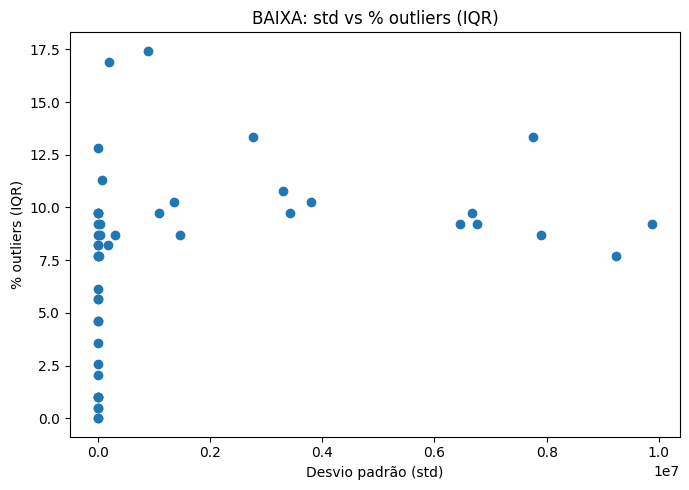

In [74]:
resumo_baixa = std_vs_outliers(base_baixa_modelo, "BAIXA", max_missing_pct=50)

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def std_vs_outliers(df, titulo, max_missing_pct=50):

    # 1) Selecionar apenas colunas numéricas
    X = df.select_dtypes(include=["float64"]).copy()

    # 2) Filtrar colunas com demasiados missing
    miss = X.isna().mean() * 100
    X = X.loc[:, miss <= max_missing_pct]

    # 3) Desvio padrão
    std = X.std(skipna=True)

    # 4) % outliers por coluna (IQR)
    q1 = X.quantile(0.25)
    q3 = X.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_pct = ((X.lt(lower)) | (X.gt(upper))).mean(skipna=True) * 100

    # 5) Tabela de síntese
    resumo = pd.DataFrame({
        "std": std,
        "outlier_pct": outlier_pct,
        "missing_pct": miss.loc[X.columns]
    }).sort_values("outlier_pct", ascending=False)

    print(f"\n=== {titulo} ===")
    print("Nº colunas analisadas:", resumo.shape[0])

    print("\nColunas ordenadas por % de outliers:")
    display(resumo.sort_values("outlier_pct", ascending=False))

    print("\nColunas ordenadas por desvio padrão:")
    display(resumo.sort_values("std", ascending=False))

    # 6) Correlação Spearman entre std e % outliers
    corr = resumo[["std", "outlier_pct"]].corr(method="spearman").iloc[0, 1]
    print(f"\nCorrelação Spearman entre std e % outliers: {corr:.3f}")

    # 7) Scatter plot
    plt.figure(figsize=(7, 5))
    plt.scatter(resumo["std"], resumo["outlier_pct"])
    plt.title(f"{titulo}: std vs % outliers (IQR)")
    plt.xlabel("Desvio padrão (std)")
    plt.ylabel("% outliers (IQR)")
    plt.tight_layout()
    plt.show()

    return resumo


=== BAIXA ===
Nº colunas analisadas: 47

Colunas ordenadas por % de outliers:


,std,outlier_pct,missing_pct
Nome_Coluna,,,
Consumo faturado não medido (dAA053b),8.941084e+05,17.435897,0.000000
Consumo não faturado não medido (dAA055b),1.996403e+05,16.923077,0.000000
Água tratada importada (dAA049b),7.759141e+06,13.333333,0.000000
Água captada (dAA064b),2.771135e+06,13.333333,11.282051
Pessoal em outsourcing afeto ao serviço de abastecimento de água (dAA018b),8.509484e+00,12.820513,0.000000
Consumo não faturado medido (dAA054b),7.072647e+04,11.282051,0.000000
Água faturada doméstica (dAA058b),3.294323e+06,10.769231,0.000000
Outros rendimentos (dAA101b),1.357452e+06,10.256410,6.666667
Água faturada não doméstica (dAA059b),3.794716e+06,10.256410,0.000000



Colunas ordenadas por desvio padrão:


,std,outlier_pct,missing_pct
Nome_Coluna,,,
Rendimentos tarifários (dAA100b),9.881531e+06,9.230769,6.666667
Gastos totais (dAA103b),9.235271e+06,7.692308,6.666667
Água entrada no sistema (dAA048b),7.902660e+06,8.717949,0.000000
Água tratada importada (dAA049b),7.759141e+06,13.333333,0.000000
Consumo autorizado (dAA051b),6.767049e+06,9.230769,0.000000
Água faturada (dAA057b),6.673689e+06,9.743590,0.000000
Consumo faturado medido (dAA052b),6.450724e+06,9.230769,0.000000
Água faturada não doméstica (dAA059b),3.794716e+06,10.256410,0.000000
Consumo de energia (dAA075b),3.420441e+06,9.743590,16.410256



Correlação Spearman entre std e % outliers: 0.590


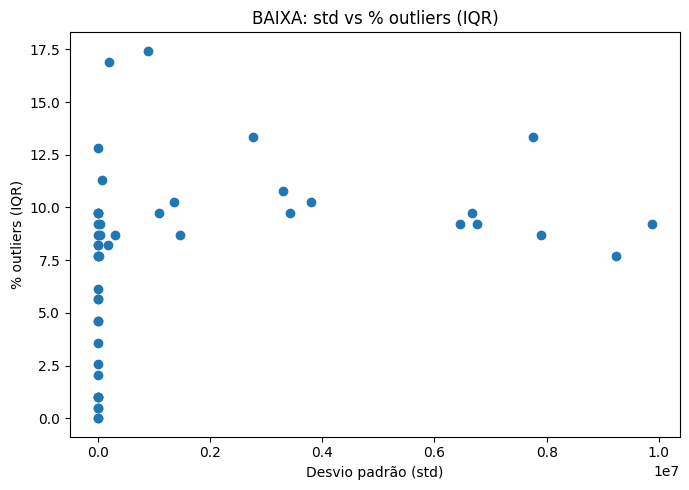

In [76]:
resumo_baixa = std_vs_outliers(base_baixa_modelo, "BAIXA", max_missing_pct=50)

#### Ver a correlação das variaveis quantitativas

In [77]:
quantitativas = base_baixa_modelo.select_dtypes(include=["float64"])
qualitativas = base_baixa_modelo.select_dtypes(exclude=["float64"])

print("Quantitativas:", quantitativas.shape[1])
print("Qualitativas:", qualitativas.columns.tolist())


Quantitativas: 47
Qualitativas: ['Empresa', 'Tipo Sistema', 'Identificação da entidade gestora (dAA001b)', 'Modelo de gestão (dAA002b)', 'Tipologia da área de intervenção (dAA025b)']


In [78]:
corr_spearman = quantitativas.corr(method="spearman")


In [79]:
!pip install plotly

In [80]:

import plotly.express as px

corr_spearman = quantitativas.corr(method="spearman")

fig = px.imshow(
    corr_spearman,
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    labels=dict(x="Variável", y="Variável", color="Correlação"),
    title="Mapa de Correlação Spearman — BAIXA"
)


fig.update_layout(
    width=1300,
    height=1200,
    font=dict(size=10),
    margin=dict(l=200, r=100, t=80, b=200)
)

# rodar labels para caber melhor
fig.update_xaxes(tickangle=45)

fig.show()




In [81]:
corr_spearman.index.name = None
corr_spearman.columns.name = None

corr_pairs = (
    corr_spearman
    .unstack()
    .reset_index()
    .rename(columns={"level_0": "Variável 1", "level_1": "Variável 2", 0: "Correlação"})
)

corr_pairs = corr_pairs[corr_pairs["Variável 1"] < corr_pairs["Variável 2"]]

corr_pairs["Correlação absoluta"] = corr_pairs["Correlação"].abs()
corr_pairs = corr_pairs.sort_values("Correlação absoluta", ascending=False)

In [82]:
corr_pairs.drop(columns="Correlação absoluta")\
    .query("Correlação > 0")\
    .head(50)

,Variável 1,Variável 2,Correlação
1926,Densidade de ramais (PAA01b),densidade_ramais,1.000000
449,Consumo faturado medido (dAA052b),Água faturada (dAA057b),0.996498
355,Consumo autorizado (dAA051b),Água faturada (dAA057b),0.996449
338,Consumo autorizado (dAA051b),Consumo faturado medido (dAA052b),0.993444
49,Alojamentos com serviço efetivo (dAA019b),Alojamentos existentes (dAA021b),0.992149
1249,Água faturada (dAA057b),Água faturada doméstica (dAA058b),0.986823
354,Consumo autorizado (dAA051b),Água entrada no sistema (dAA048b),0.984199
356,Consumo autorizado (dAA051b),Água faturada doméstica (dAA058b),0.983976
450,Consumo faturado medido (dAA052b),Água faturada doméstica (dAA058b),0.982133
193,Comprimento médio de condutas com mais de 10 a...,Comprimento total de condutas (dAA026b),0.981884


In [83]:
import plotly.graph_objects as go

bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
labels = ["0-10%", "10-20%", "20-30%", "30-40%", "40-50%", "50-60%", "60-70%", "70-80%", "80-90%", "90-100%"]

corr_pos = corr_pairs[corr_pairs["Correlação"] > 0].copy()
corr_pos["intervalo"] = pd.cut(corr_pos["Correlação"].abs(), bins=bins, labels=labels, include_lowest=True)
dist_pos = corr_pos.groupby("intervalo", observed=False).size().reset_index(name="n_pares")

fig = go.Figure(go.Bar(
    x=dist_pos["intervalo"],
    y=dist_pos["n_pares"],
    text=dist_pos["n_pares"],
    textposition="outside",
    marker=dict(
        color=dist_pos["n_pares"],
        colorscale=[[0, "#cce5ff"], [1, "#004080"]],
        showscale=False
    ),
))

fig.update_layout(
    title="Distribuição dos pares — Correlações positivas (Spearman)",
    xaxis_title="Intervalo de correlação",
    yaxis_title="Número de pares",
    plot_bgcolor="white",
    height=500,
    width=800,
    xaxis=dict(categoryorder="array", categoryarray=labels)
)
fig.update_yaxes(gridcolor="lightgrey")
fig.show()

In [84]:
corr_pairs.drop(columns="Correlação absoluta")\
    .query("Correlação < 0")\
    .head(50)

,Variável 1,Variável 2,Correlação
1361,Água faturada não doméstica (dAA059b),Água não faturada (AA08b),-0.680551
1079,Rendimentos tarifários (dAA100b),Água não faturada (AA08b),-0.671402
468,Consumo faturado medido (dAA052b),Água não faturada (AA08b),-0.659318
1267,Água faturada (dAA057b),Água não faturada (AA08b),-0.657610
797,Outros rendimentos (dAA101b),Água não faturada (AA08b),-0.641121
1314,Água faturada doméstica (dAA058b),Água não faturada (AA08b),-0.635872
1878,Cobertura dos gastos (AA06b),Água não faturada (AA08b),-0.633364
374,Consumo autorizado (dAA051b),Água não faturada (AA08b),-0.631159
750,Gastos totais (dAA103b),Água não faturada (AA08b),-0.615849
1786,Adesão ao serviço (AA07b),Alojamentos com serviço disponível não efetivo...,-0.579408


In [85]:
corr_neg = corr_pairs[corr_pairs["Correlação"] < 0].copy()
corr_neg["intervalo"] = pd.cut(corr_neg["Correlação"].abs(), bins=bins, labels=labels, include_lowest=True)
dist_neg = corr_neg.groupby("intervalo", observed=False).size().reset_index(name="n_pares")

fig = go.Figure(go.Bar(
    x=dist_neg["intervalo"],
    y=dist_neg["n_pares"],
    text=dist_neg["n_pares"],
    textposition="outside",
    marker=dict(color=dist_neg["n_pares"], colorscale="Reds", showscale=False),
))

fig.update_layout(
    title="Distribuição dos pares — Correlações negativas (Spearman)",
    xaxis_title="Intervalo de correlação",
    yaxis_title="Número de pares",
    plot_bgcolor="white",
    height=500,
    width=800,
    xaxis=dict(categoryorder="array", categoryarray=labels)
)
fig.update_yaxes(gridcolor="lightgrey")
fig.show()

3.	Correlações das variáveis-alvo com os restantes atributos quantitativos

In [86]:
col_perdas = [c for c in quantitativas.columns if "(AA15b)" in c][0]
col_anf = [c for c in quantitativas.columns if "(AA08b)" in c][0]

col_perdas, col_anf


('Perdas reais de água (AA15b)', 'Água não faturada (AA08b)')

In [87]:
targets = [col_perdas, col_anf]

corr_targets = quantitativas.corr(method="spearman").loc[
    :, targets
]


In [88]:
import plotly.express as px

fig = px.imshow(
    corr_targets,
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Correlação Spearman — Perdas Reais e Água Não Faturada",
    labels=dict(x="Variável alvo", y="Variáveis", color="Correlação")
)

fig.update_layout(
    width=900,
    height=1200,
    margin=dict(l=250, r=100, t=80, b=80),
    font=dict(size=10)
)

fig.show()


In [89]:
corr_targets[col_perdas].sort_values(ascending=False).head(10)


,Perdas reais de água (AA15b)
Perdas reais de água (AA15b),1.000000
Perdas reais (dAA062b),0.496390
Água não faturada (AA08b),0.477695
Água não faturada (dAA060b),0.428277
Ocorrência de falhas no abastecimento (AA03b),0.273302
Ocorrência de avarias em condutas (AA10b),0.242414
Consumo de energia (dAA075b),0.223164
Falhas no abastecimento (dAA041b),0.200056
Adesão ao serviço (AA07b),0.188690
Consumo não faturado medido (dAA054b),0.165377


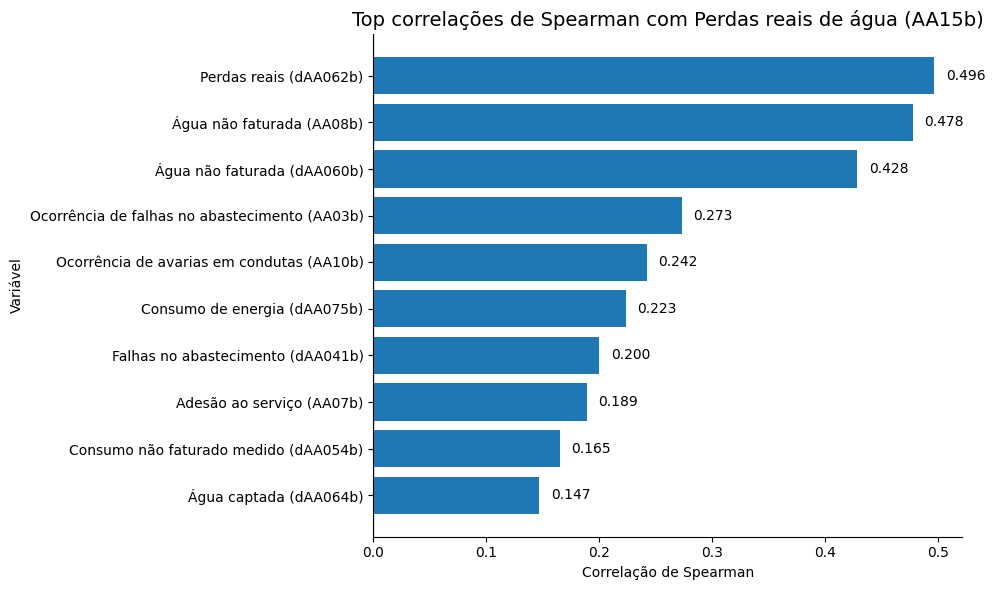

In [90]:
import matplotlib.pyplot as plt

# Top 10 correlações com a variável de perdas reais
top_corr = (
    corr_targets[col_perdas]
    .dropna()
    .drop(labels=[col_perdas], errors="ignore")
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

bars = plt.barh(top_corr.index[::-1], top_corr.values[::-1])

plt.title("Top correlações de Spearman com Perdas reais de água (AA15b)", fontsize=14)
plt.xlabel("Correlação de Spearman")
plt.ylabel("Variável")

# Linha vertical no zero
plt.axvline(0, color="gray", linewidth=1)

# Valores no fim de cada barra
for i, v in enumerate(top_corr.values[::-1]):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=10)

# Tirar bordas de cima e da direita
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

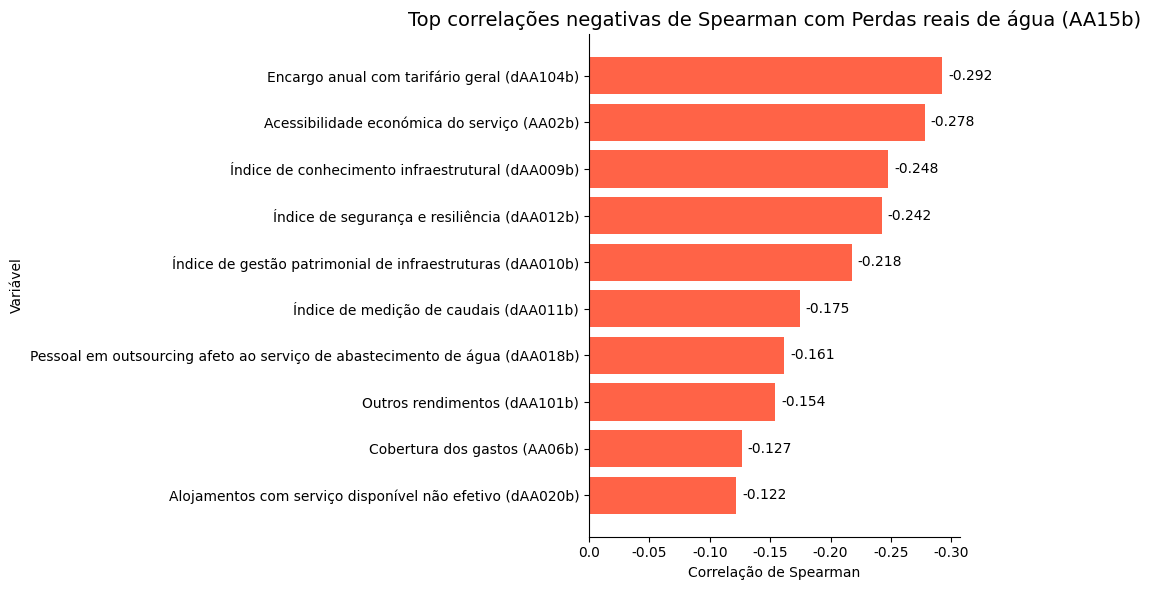

In [91]:
import matplotlib.pyplot as plt

# Top 15 correlações negativas com a variável de perdas reais
top_corr = (
    corr_targets[col_perdas]
    .dropna()
    .sort_values(ascending=True)
    .head(10)
)

# Remover a autocorrelação, se estiver incluída
top_corr = top_corr[top_corr.index != col_perdas]

plt.figure(figsize=(10, 6), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

# Plotar valores absolutos para as barras irem da esquerda para a direita
bars = plt.barh(top_corr.index[::-1], top_corr.abs().values[::-1], color="tomato")

plt.title("Top correlações negativas de Spearman com Perdas reais de água (AA15b)", fontsize=14)
plt.xlabel("Correlação de Spearman")
plt.ylabel("Variável")

# Valores no fim de cada barra (com sinal negativo)
for i, v in enumerate(top_corr.values[::-1]):
    plt.text(abs(v) + 0.005, i, f"{v:.3f}", va="center", ha="left", fontsize=10)

# Tirar bordas de cima e da direita
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Formatar o eixo X com sinal negativo
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"-{x:.2f}" if x > 0 else "0.0"))

plt.tight_layout()
plt.show()

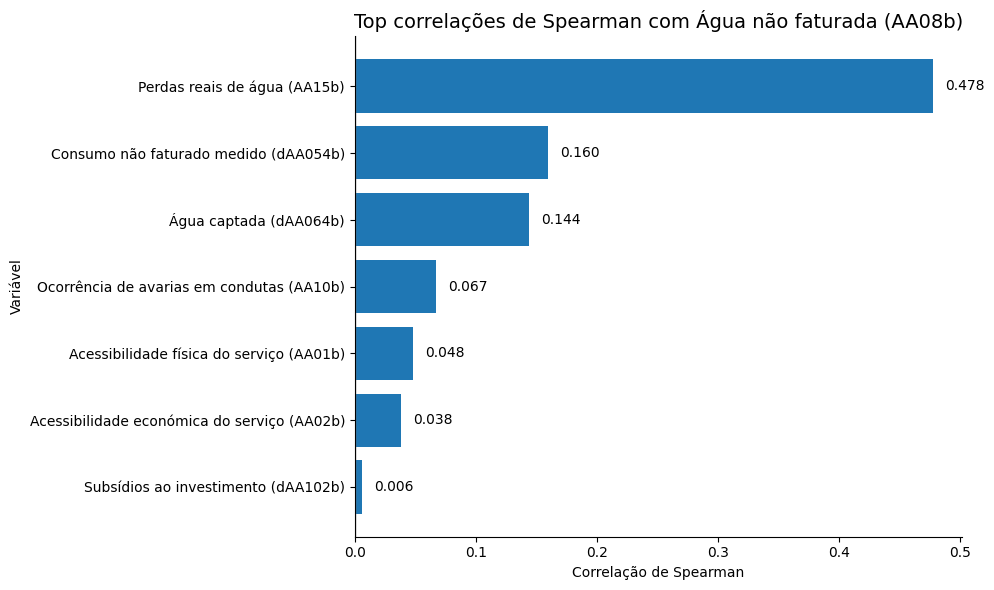

In [92]:
import matplotlib.pyplot as plt

# Top 10 correlações com a variável Água não faturada
top_corr = (
    corr_targets[col_anf]
    .dropna()
    .drop(labels=[col_anf], errors="ignore")
    .sort_values(ascending=False)
    .head(7)
)

plt.figure(figsize=(10, 6), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

bars = plt.barh(top_corr.index[::-1], top_corr.values[::-1])

plt.title("Top correlações de Spearman com Água não faturada (AA08b)", fontsize=14)
plt.xlabel("Correlação de Spearman")
plt.ylabel("Variável")

# Linha vertical no zero
plt.axvline(0, color="gray", linewidth=1)

# Valores no fim de cada barra
for i, v in enumerate(top_corr.values[::-1]):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=10)

# Tirar bordas de cima e da direita
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

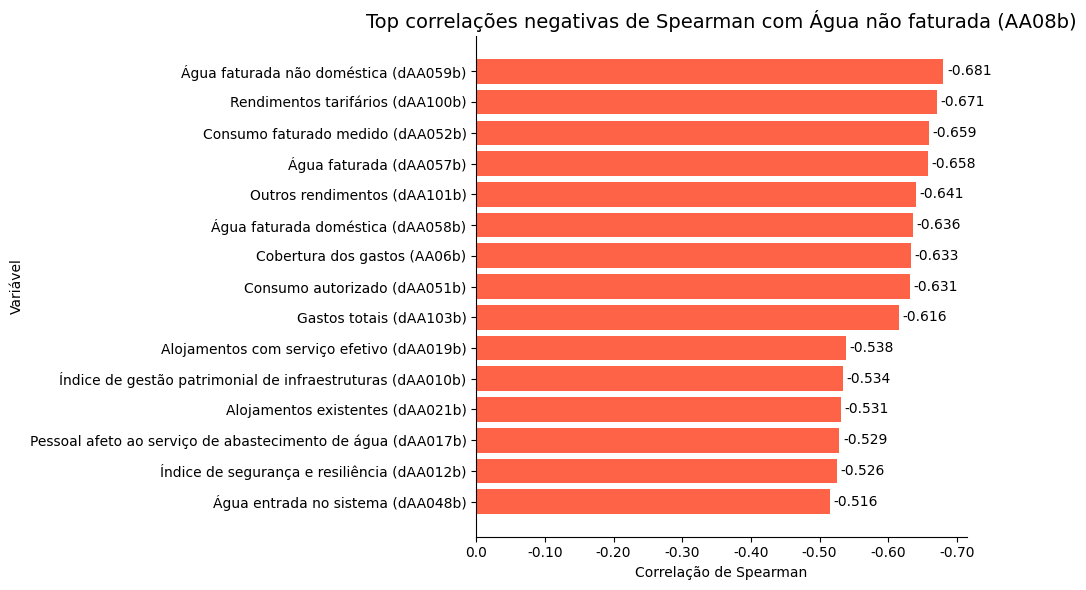

In [93]:
import matplotlib.pyplot as plt

# Top 10 correlações negativas com a variável Água não faturada
top_corr = (
    corr_targets[col_anf]
    .dropna()
    .sort_values(ascending=True)
    .head(15)
)

# Remover a autocorrelação, se estiver incluída
top_corr = top_corr[top_corr.index != col_anf]

plt.figure(figsize=(10, 6), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

# Plotar valores absolutos para as barras irem da esquerda para a direita
bars = plt.barh(top_corr.index[::-1], top_corr.abs().values[::-1], color="tomato")

plt.title("Top correlações negativas de Spearman com Água não faturada (AA08b)", fontsize=14)
plt.xlabel("Correlação de Spearman")
plt.ylabel("Variável")

# Valores no fim de cada barra (com sinal negativo)
for i, v in enumerate(top_corr.values[::-1]):
    plt.text(abs(v) + 0.005, i, f"{v:.3f}", va="center", ha="left", fontsize=10)

# Tirar bordas de cima e da direita
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Formatar o eixo X com sinal negativo
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"-{x:.2f}" if x > 0 else "0.0"))

plt.tight_layout()
plt.show()

In [94]:
import pandas as pd

# Correlações com Água não faturada
corr_anf = (
    corr_targets[col_anf]
    .dropna()
    .drop(labels=[col_anf], errors="ignore")
)

# Selecionar negativas e usar valor absoluto
corr_neg = corr_anf[corr_anf < 0].abs() * 100

# Intervalos
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
labels = ["0-10%", "10-20%", "20-30%", "30-40%", "40-50%", "50-60%", "60-70%", "70-80%", "80-90%", "90-100%"]

# Contagem por intervalo
intervalos = pd.cut(corr_neg, bins=bins, labels=labels, include_lowest=True, right=True)
contagem_neg = intervalos.value_counts().sort_index()

print(contagem_neg)

Água não faturada (AA08b)
0-10%      3
10-20%     3
20-30%     7
30-40%     2
40-50%     6
50-60%     9
60-70%     9
70-80%     0
80-90%     0
90-100%    0
Name: count, dtype: int64


##### Ver se os missing values têm relação entre si nas variaveis quantitativas

In [95]:
missing_matrix = quantitativas.isna().astype(int)

In [96]:
missing_por_coluna = missing_matrix.sum().sort_values(ascending=False)

display(missing_por_coluna)

n_colunas_missing = (missing_por_coluna > 0).sum()

print("Número total de colunas com missing values:", n_colunas_missing)

,0
Consumo de energia (dAA075b),32
Água captada (dAA064b),22
Cobertura dos gastos (AA06b),13
Outros rendimentos (dAA101b),13
Rendimentos tarifários (dAA100b),13
Gastos totais (dAA103b),13
Subsídios ao investimento (dAA102b),13
Falhas no abastecimento (dAA041b),12
Ocorrência de falhas no abastecimento (AA03b),12
Ocorrência de avarias em condutas (AA10b),6


Número total de colunas com missing values: 17


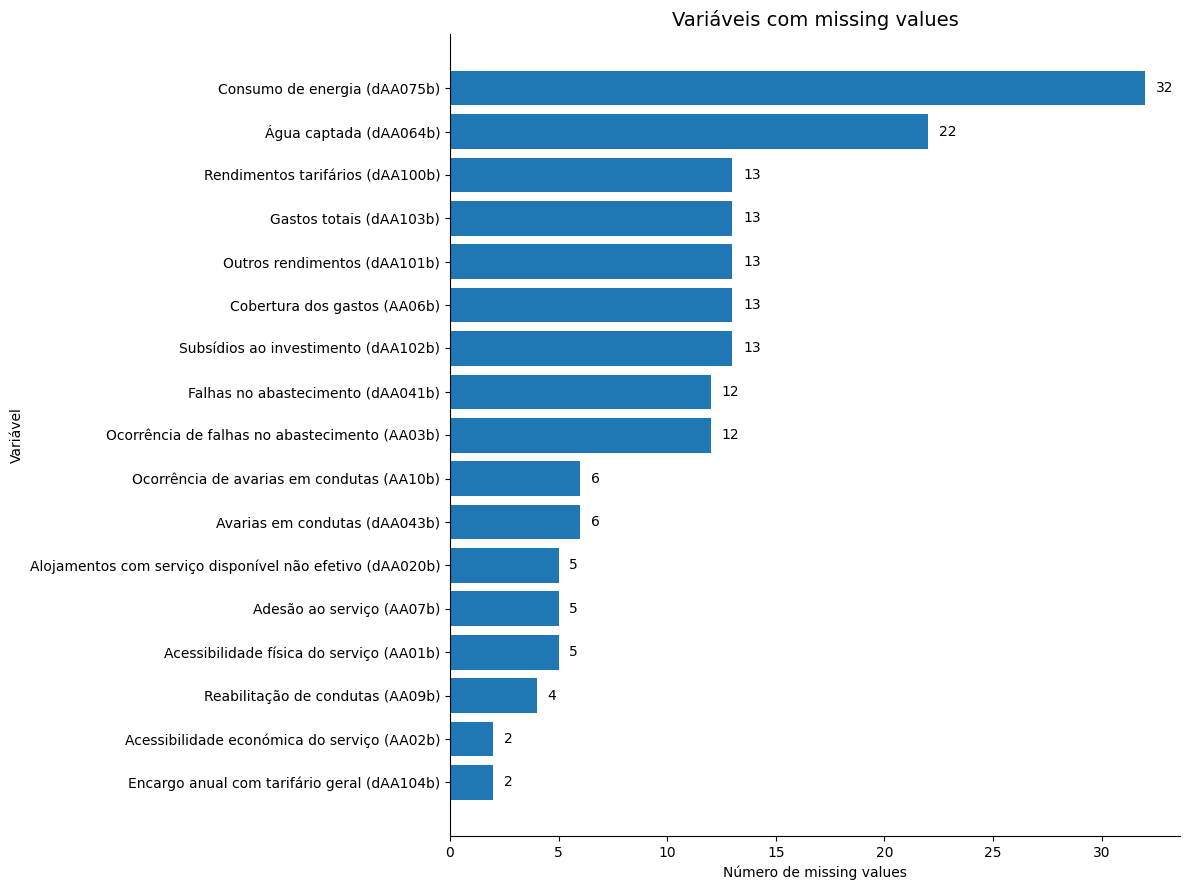

In [97]:
import matplotlib.pyplot as plt

missing_matrix = quantitativas.isna().astype(int)
missing_por_coluna = missing_matrix.sum().sort_values(ascending=False)
missing_por_coluna = missing_por_coluna[missing_por_coluna > 0]
missing_por_coluna = missing_por_coluna.sort_values(ascending=True)

plt.figure(figsize=(12, 9), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

plt.barh(missing_por_coluna.index, missing_por_coluna.values)

plt.title("Variáveis com missing values", fontsize=14)
plt.xlabel("Número de missing values")
plt.ylabel("Variável")

for i, v in enumerate(missing_por_coluna.values):
    plt.text(v + 0.5, i, str(v), va="center", fontsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [98]:
corr_missing = missing_matrix.corr(method="spearman")

In [99]:
import plotly.express as px

fig = px.imshow(
    corr_missing,
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Correlação entre Missing Values (Variáveis Numéricas)",
    labels=dict(color="Correlação")
)

fig.update_layout(
    width=1200,
    height=1000,
    margin=dict(l=200, r=100, t=80, b=200),
    font=dict(size=10)
)

fig.update_xaxes(tickangle=45)

fig.show()

In [100]:
corr_missing.index.name = None
corr_missing.columns.name = None

missing_pairs = (
    corr_missing
    .unstack()
    .reset_index()
    .rename(columns={"level_0": "Variável 1", "level_1": "Variável 2", 0: "Correlação"})
)

missing_pairs = missing_pairs[missing_pairs["Variável 1"] < missing_pairs["Variável 2"]]
missing_pairs["Correlação absoluta"] = missing_pairs["Correlação"].abs()
missing_pairs = missing_pairs.sort_values("Correlação absoluta", ascending=False)

In [101]:
corr_missing.index.name = None
corr_missing.columns.name = None

missing_pairs = (
    corr_missing
    .stack()
    .reset_index(name="Correlação")
)

missing_pairs.columns = ["Variável 1", "Variável 2", "Correlação"]

missing_pairs = missing_pairs[
    missing_pairs["Variável 1"] < missing_pairs["Variável 2"]
].copy()

missing_pairs["Correlação absoluta"] = missing_pairs["Correlação"].abs()

missing_pairs_positivos = (
    missing_pairs[missing_pairs["Correlação"] > 0]
    .sort_values("Correlação absoluta", ascending=False)
    .drop(columns="Correlação absoluta")
    .head(60)
    .reset_index(drop=True)
)

display(
    missing_pairs_positivos.style
    .format({"Correlação": "{:.3f}"})
    .set_table_styles([
        {
            "selector": "table",
            "props": [
                ("background-color", "white"),
                ("color", "black"),
                ("border-collapse", "collapse"),
                ("font-size", "12px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#f2f2f2"),
                ("color", "black"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid #d9d9d9"),
                ("padding", "6px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("background-color", "white"),
                ("color", "black"),
                ("border", "1px solid #e0e0e0"),
                ("padding", "6px"),
                ("text-align", "left")
            ]
        }
    ])
)

,Variável 1,Variável 2,Correlação
0,Avarias em condutas (dAA043b),Ocorrência de avarias em condutas (AA10b),1.000
1,Gastos totais (dAA103b),Rendimentos tarifários (dAA100b),1.000
2,Gastos totais (dAA103b),Subsídios ao investimento (dAA102b),1.000
3,Outros rendimentos (dAA101b),Rendimentos tarifários (dAA100b),1.000
4,Outros rendimentos (dAA101b),Subsídios ao investimento (dAA102b),1.000
5,Rendimentos tarifários (dAA100b),Subsídios ao investimento (dAA102b),1.000
6,Acessibilidade económica do serviço (AA02b),Encargo anual com tarifário geral (dAA104b),1.000
7,Falhas no abastecimento (dAA041b),Ocorrência de falhas no abastecimento (AA03b),1.000
8,Acessibilidade física do serviço (AA01b),Alojamentos com serviço disponível não efetivo (dAA020b),1.000
9,Cobertura dos gastos (AA06b),Gastos totais (dAA103b),1.000


In [102]:
corr_missing.index.name = None
corr_missing.columns.name = None

missing_pairs = (
    corr_missing
    .stack()
    .reset_index(name="Correlação")
)

missing_pairs.columns = ["Variável 1", "Variável 2", "Correlação"]

missing_pairs = missing_pairs[
    missing_pairs["Variável 1"] < missing_pairs["Variável 2"]
].copy()

missing_pairs["Correlação absoluta"] = missing_pairs["Correlação"].abs()

missing_pairs_negativos = (
    missing_pairs[missing_pairs["Correlação"] < 0]
    .sort_values("Correlação absoluta", ascending=False)
    .drop(columns="Correlação absoluta")
    .head(60)
    .reset_index(drop=True)
)

display(
    missing_pairs_negativos.style
    .format({"Correlação": "{:.3f}"})
    .set_table_styles([
        {
            "selector": "table",
            "props": [
                ("background-color", "white"),
                ("color", "black"),
                ("border-collapse", "collapse"),
                ("font-size", "12px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#f2f2f2"),
                ("color", "black"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid #d9d9d9"),
                ("padding", "6px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("background-color", "white"),
                ("color", "black"),
                ("border", "1px solid #e0e0e0"),
                ("padding", "6px"),
                ("text-align", "left")
            ]
        }
    ])
)

,Variável 1,Variável 2,Correlação
0,Alojamentos com serviço disponível não efetivo (dAA020b),Consumo de energia (dAA075b),-0.072
1,Acessibilidade física do serviço (AA01b),Consumo de energia (dAA075b),-0.072
2,Adesão ao serviço (AA07b),Consumo de energia (dAA075b),-0.072
3,Falhas no abastecimento (dAA041b),Rendimentos tarifários (dAA100b),-0.068
4,Falhas no abastecimento (dAA041b),Subsídios ao investimento (dAA102b),-0.068
5,Cobertura dos gastos (AA06b),Ocorrência de falhas no abastecimento (AA03b),-0.068
6,Falhas no abastecimento (dAA041b),Gastos totais (dAA103b),-0.068
7,Ocorrência de falhas no abastecimento (AA03b),Subsídios ao investimento (dAA102b),-0.068
8,Cobertura dos gastos (AA06b),Falhas no abastecimento (dAA041b),-0.068
9,Ocorrência de falhas no abastecimento (AA03b),Rendimentos tarifários (dAA100b),-0.068


In [103]:
base_baixa_modelo.shape

(195, 52)

In [104]:
missing_pairs.drop(columns="Correlação absoluta")\
    .query("Correlação > 0")\
    .head(60)

,Variável 1,Variável 2,Correlação
1,Alojamentos com serviço disponível não efetivo...,Avarias em condutas (dAA043b),0.158970
4,Alojamentos com serviço disponível não efetivo...,Falhas no abastecimento (dAA041b),0.093466
5,Alojamentos com serviço disponível não efetivo...,Gastos totais (dAA103b),0.216777
6,Alojamentos com serviço disponível não efetivo...,Outros rendimentos (dAA101b),0.216777
7,Alojamentos com serviço disponível não efetivo...,Rendimentos tarifários (dAA100b),0.216777
8,Alojamentos com serviço disponível não efetivo...,Subsídios ao investimento (dAA102b),0.216777
9,Alojamentos com serviço disponível não efetivo...,Água captada (dAA064b),0.044702
13,Alojamentos com serviço disponível não efetivo...,Cobertura dos gastos (AA06b),0.216777
14,Alojamentos com serviço disponível não efetivo...,Ocorrência de avarias em condutas (AA10b),0.158970
15,Alojamentos com serviço disponível não efetivo...,Ocorrência de falhas no abastecimento (AA03b),0.093466


In [105]:
missing_pairs.drop(columns="Correlação absoluta")\
    .query("Correlação < 0")\
    .head(60)

,Variável 1,Variável 2,Correlação
2,Alojamentos com serviço disponível não efetivo...,Consumo de energia (dAA075b),-0.071877
3,Alojamentos com serviço disponível não efetivo...,Encargo anual com tarifário geral (dAA104b),-0.016514
20,Avarias em condutas (dAA043b),Encargo anual com tarifário geral (dAA104b),-0.018138
22,Avarias em condutas (dAA043b),Gastos totais (dAA103b),-0.047619
23,Avarias em condutas (dAA043b),Outros rendimentos (dAA101b),-0.047619
24,Avarias em condutas (dAA043b),Rendimentos tarifários (dAA100b),-0.047619
25,Avarias em condutas (dAA043b),Subsídios ao investimento (dAA102b),-0.047619
30,Avarias em condutas (dAA043b),Cobertura dos gastos (AA06b),-0.047619
33,Avarias em condutas (dAA043b),Reabilitação de condutas (AA09b),-0.025784
37,Consumo de energia (dAA075b),Encargo anual com tarifário geral (dAA104b),-0.045104


#### Ver a correlação das variaveis qualitativas

In [106]:
qualitativas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 195 entries, 0 to 227
Data columns (total 5 columns):
 #   Column                                       Non-Null Count  Dtype 
---  ------                                       --------------  ----- 
 0   Empresa                                      195 non-null    object
 1   Tipo Sistema                                 195 non-null    object
 2   Identificação da entidade gestora (dAA001b)  195 non-null    object
 3   Modelo de gestão (dAA002b)                   195 non-null    object
 4   Tipologia da área de intervenção (dAA025b)   195 non-null    object
dtypes: object(5)
memory usage: 13.2+ KB


Agua nao faturada -> Modelo de gestão

In [107]:
import plotly.express as px

# Colunas
col_anf_percn = encontrar_coluna_por_codigo(base_baixa_modelo, "AA08b")
col_modelo = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA002b")

# Base para o gráfico
df_plot = base_baixa_modelo.dropna(subset=[col_modelo, col_anf_percn]).copy()

# Garantir variável numérica
df_plot[col_anf_percn] = pd.to_numeric(df_plot[col_anf_percn], errors="coerce")
df_plot = df_plot.dropna(subset=[col_anf_percn])

# Agregar categorias
serie_modelo = df_plot[col_modelo].astype(str)

df_plot["modelo_gestao_agregado"] = np.select(
    [
        serie_modelo.str.contains("Gestão direta", case=False, na=False),
        serie_modelo.str.contains("Delegação", case=False, na=False),
        serie_modelo.str.contains("Concessão", case=False, na=False),
    ],
    [
        "Gestão direta",
        "Delegação",
        "Concessão"
    ],
    default="Outros"
)

# Remover categoria residual
df_plot = df_plot[df_plot["modelo_gestao_agregado"] != "Outros"].copy()

# Ordem crescente pela mediana
ordem = (
    df_plot.groupby("modelo_gestao_agregado")[col_anf_percn]
    .median()
    .sort_values()
    .index
    .tolist()
)

# Contagens
contagens = (
    df_plot["modelo_gestao_agregado"]
    .value_counts()
    .reindex(ordem)
)

# Rótulos do eixo X
rotulos = {
    cat: f"{cat}<br>(n={contagens[cat]})"
    for cat in ordem
}

# Cores um pouco mais carregadas
cores = {
    "Concessão": "#4F93B3",
    "Delegação": "#B05C8A",
    "Gestão direta": "#D98C1F"
}

# Gráfico
fig = px.box(
    df_plot,
    x="modelo_gestao_agregado",
    y=col_anf_percn,
    color="modelo_gestao_agregado",
    points="all",
    category_orders={"modelo_gestao_agregado": ordem},
    color_discrete_map=cores,
    title="Água não faturada por Modelo de Gestão"
)

fig.update_traces(
    jitter=0.28,
    pointpos=-1.6,
    marker=dict(size=6, opacity=0.60),
    line=dict(width=2)
)

fig.update_layout(
    template="simple_white",
    height=650,
    width=1150,
    font=dict(size=14),
    title=dict(
        text="Água não faturada por Modelo de Gestão",
        x=0.01,
        xanchor="left",
        font=dict(size=24)
    ),
    xaxis_title="Modelo de gestão",
    yaxis_title="Água não faturada (%)",
    margin=dict(t=70, l=60, r=20, b=80),
    showlegend=False
)

fig.update_xaxes(
    tickmode="array",
    tickvals=ordem,
    ticktext=[rotulos[c] for c in ordem],
    showgrid=False
)

fig.update_yaxes(
    ticksuffix="%",
    gridcolor="rgba(150,150,150,0.25)",
    zeroline=False
)

fig.show()

In [108]:
import numpy as np
import pandas as pd

# =========================
# COLUNAS
# =========================
col_anf_percn = encontrar_coluna_por_codigo(base_baixa_modelo, "AA08b")
col_modelo = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA002b")
col_perdas_LR = encontrar_coluna_por_codigo(base_baixa_modelo, "AA15b")

# =========================
# BASE
# =========================
df = base_baixa_modelo.copy()

# garantir numérico
df[col_anf_percn] = pd.to_numeric(df[col_anf_percn], errors="coerce")
df[col_perdas_LR] = pd.to_numeric(df[col_perdas_LR], errors="coerce")
df["densidade_ramais"] = pd.to_numeric(df["densidade_ramais"], errors="coerce")

# remover missing essenciais
df = df.dropna(subset=[col_modelo, col_anf_percn]).copy()

# =========================
# AGRUPAR MODELO DE GESTÃO
# =========================
serie_modelo = df[col_modelo].astype(str)

df["modelo_gestao_agregado"] = np.select(
    [
        serie_modelo.str.contains("Gestão direta", case=False, na=False),
        serie_modelo.str.contains("Delegação", case=False, na=False),
        serie_modelo.str.contains("Concessão", case=False, na=False),
    ],
    [
        "Gestão direta",
        "Delegação",
        "Concessão"
    ],
    default="Outros"
)

# remover categoria residual
df = df[df["modelo_gestao_agregado"] != "Outros"].copy()

# =========================
# FUNÇÕES AUXILIARES
# =========================
def calcular_limites_iqr(serie):
    serie = pd.to_numeric(serie, errors="coerce").dropna()

    if serie.empty:
        return np.nan, np.nan

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return lower, upper


def identificar_outliers_iqr(serie, lower=None, upper=None):
    serie = pd.to_numeric(serie, errors="coerce")

    if lower is None or upper is None:
        lower, upper = calcular_limites_iqr(serie)

    return (serie < lower) | (serie > upper)


def tabela_outliers_anf(df, grupo):
    df_g = df[df["modelo_gestao_agregado"] == grupo].copy()

    if df_g.empty:
        return pd.DataFrame()

    # outliers de ANF no grupo
    lower_anf, upper_anf = calcular_limites_iqr(df_g[col_anf_percn])
    df_g["outlier_anf"] = identificar_outliers_iqr(
        df_g[col_anf_percn],
        lower=lower_anf,
        upper=upper_anf
    )

    # estado inicial de perdas
    df_g["outlier_perdas"] = "Sem valor"

    mask_densidade_baixa = df_g["densidade_ramais"] < 20
    mask_perdas_validas = (
        (df_g["densidade_ramais"] >= 20) &
        (df_g[col_perdas_LR].notna())
    )

    df_g.loc[mask_densidade_baixa, "outlier_perdas"] = "Densidade < 20"

    if mask_perdas_validas.sum() > 0:
        lower_perdas, upper_perdas = calcular_limites_iqr(
            df_g.loc[mask_perdas_validas, col_perdas_LR]
        )

        df_g.loc[mask_perdas_validas, "outlier_perdas"] = identificar_outliers_iqr(
            df_g.loc[mask_perdas_validas, col_perdas_LR],
            lower=lower_perdas,
            upper=upper_perdas
        ).map({
            True: "Outlier",
            False: "Não outlier"
        })

    # filtrar apenas outliers de ANF
    resultado = df_g.loc[df_g["outlier_anf"]].copy()

    # seleção final
    resultado = resultado[[
        "Empresa",
        "modelo_gestao_agregado",
        col_anf_percn,
        "outlier_anf",
        col_perdas_LR,
        "outlier_perdas",
        "densidade_ramais"
    ]].rename(columns={
        "Empresa": "Empresa",
        "modelo_gestao_agregado": "Modelo de gestão",
        col_anf_percn: "Água não faturada (AA08b)",
        "outlier_anf": "Outlier ANF",
        col_perdas_LR: "Perdas reais de água (AA15b)",
        "outlier_perdas": "Outlier perdas",
        "densidade_ramais": "Densidade ramais"
    })

    # arredondar
    colunas_numericas = [
        "Água não faturada (AA08b)",
        "Perdas reais de água (AA15b)",
        "Densidade ramais"
    ]
    resultado[colunas_numericas] = resultado[colunas_numericas].round(1)

    # ordenar
    resultado = resultado.sort_values(
        by="Água não faturada (AA08b)",
        ascending=False
    ).reset_index(drop=True)

    return resultado


# =========================
# TABELAS POR GRUPO
# =========================
tabela_gestao_direta_anf = tabela_outliers_anf(df, "Gestão direta")
tabela_delegacao_anf = tabela_outliers_anf(df, "Delegação")
tabela_concessao_anf = tabela_outliers_anf(df, "Concessão")

# =========================
# TABELA TOTAL
# =========================
tabela_outliers_anf_total = pd.concat(
    [
        tabela_gestao_direta_anf,
        tabela_delegacao_anf,
        tabela_concessao_anf
    ],
    ignore_index=True
)

# garantir índice simples e sem nome estranho nas colunas
tabela_outliers_anf_total = tabela_outliers_anf_total.reset_index(drop=True)
tabela_outliers_anf_total.columns.name = None

# mostrar sem índice
display(
    tabela_outliers_anf_total.style
    .hide(axis="index")
    .format({
        "Água não faturada (AA08b)": "{:.1f}",
        "Perdas reais de água (AA15b)": "{:.1f}",
        "Densidade ramais": "{:.1f}"
    })
)

Empresa,Modelo de gestão,Água não faturada (AA08b),Outlier ANF,Perdas reais de água (AA15b),Outlier perdas,Densidade ramais
CM de Vila Nova de Cerveira,Gestão direta,84.8,True,11.1,Densidade < 20,14.0
Águas de Carrazeda,Concessão,40.6,True,74.0,Não outlier,27.0
Aquaelvas,Concessão,38.8,True,157.0,Outlier,39.0


In [109]:
import numpy as np
import pandas as pd
import plotly.express as px

# =========================
# COLUNAS
# =========================
col_anf_m3 = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA060b")
col_modelo = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA002b")
col_rede = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA026b")

# =========================
# BASE
# =========================
df_plot = base_baixa_modelo.copy()

# garantir numérico
df_plot[col_anf_m3] = pd.to_numeric(df_plot[col_anf_m3], errors="coerce")
df_plot[col_rede] = pd.to_numeric(df_plot[col_rede], errors="coerce")

# remover missing
df_plot = df_plot.dropna(subset=[col_modelo, col_anf_m3, col_rede]).copy()

# evitar divisão por zero
df_plot = df_plot[df_plot[col_rede] > 0].copy()

# =========================
# INDICADOR NORMALIZADO
# =========================
df_plot["anf_m3_km_ano"] = df_plot[col_anf_m3] / df_plot[col_rede]

# remover infinitos / missing depois do cálculo
df_plot["anf_m3_km_ano"] = pd.to_numeric(df_plot["anf_m3_km_ano"], errors="coerce")
df_plot = df_plot.replace([np.inf, -np.inf], np.nan)
df_plot = df_plot.dropna(subset=["anf_m3_km_ano"]).copy()

# =========================
# AGRUPAR MODELO DE GESTÃO
# =========================
serie_modelo = df_plot[col_modelo].astype(str)

df_plot["modelo_gestao_agregado"] = np.select(
    [
        serie_modelo.str.contains("Gestão direta", case=False, na=False),
        serie_modelo.str.contains("Delegação", case=False, na=False),
        serie_modelo.str.contains("Concessão", case=False, na=False),
    ],
    [
        "Gestão direta",
        "Delegação",
        "Concessão"
    ],
    default="Outros"
)

# remover categoria residual
df_plot = df_plot[df_plot["modelo_gestao_agregado"] != "Outros"].copy()

# =========================
# ORDEM POR MEDIANA
# =========================
ordem = (
    df_plot.groupby("modelo_gestao_agregado")["anf_m3_km_ano"]
    .median()
    .sort_values()
    .index
    .tolist()
)

# =========================
# CONTAGENS
# =========================
contagens = (
    df_plot["modelo_gestao_agregado"]
    .value_counts()
    .reindex(ordem)
)

rotulos = {
    cat: f"{cat}<br>(n={contagens[cat]})"
    for cat in ordem
}

# =========================
# CORES
# =========================
cores = {
    "Concessão": "#4F93B3",
    "Delegação": "#B05C8A",
    "Gestão direta": "#D98C1F"
}

# =========================
# BOXPLOT
# =========================
fig = px.box(
    df_plot,
    x="modelo_gestao_agregado",
    y="anf_m3_km_ano",
    color="modelo_gestao_agregado",
    points="all",
    category_orders={"modelo_gestao_agregado": ordem},
    color_discrete_map=cores,
    title="Água não faturada (m³/km/ano) por Modelo de Gestão"
)

fig.update_traces(
    jitter=0.28,
    pointpos=-1.6,
    marker=dict(size=6, opacity=0.60),
    line=dict(width=2)
)

fig.update_layout(
    template="simple_white",
    height=650,
    width=1150,
    font=dict(size=14),
    title=dict(
        text="Água não faturada (m³/km/ano) por Modelo de Gestão",
        x=0.01,
        xanchor="left",
        font=dict(size=24)
    ),
    xaxis_title="Modelo de gestão",
    yaxis_title="Água não faturada (m³/km/ano)",
    margin=dict(t=70, l=60, r=20, b=80),
    showlegend=False
)

fig.update_xaxes(
    tickmode="array",
    tickvals=ordem,
    ticktext=[rotulos[c] for c in ordem],
    showgrid=False
)

fig.update_yaxes(
    gridcolor="rgba(150,150,150,0.25)",
    zeroline=False
)

fig.show()

In [110]:
import numpy as np
import pandas as pd
import plotly.express as px

# =========================
# COLUNAS
# =========================
col_anf_m3 = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA060b")
col_modelo = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA002b")
col_rede = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA026b")

# =========================
# BASE
# =========================
df_plot = base_baixa_modelo.copy()

# garantir numérico
df_plot[col_anf_m3] = pd.to_numeric(df_plot[col_anf_m3], errors="coerce")
df_plot[col_rede] = pd.to_numeric(df_plot[col_rede], errors="coerce")

# remover missing
df_plot = df_plot.dropna(subset=[col_modelo, col_anf_m3, col_rede]).copy()

# evitar divisão por zero
df_plot = df_plot[df_plot[col_rede] > 0].copy()

# =========================
# INDICADOR NORMALIZADO
# =========================
df_plot["anf_m3_km_ano"] = df_plot[col_anf_m3] / df_plot[col_rede]

# remover infinitos / missing depois do cálculo
df_plot["anf_m3_km_ano"] = pd.to_numeric(df_plot["anf_m3_km_ano"], errors="coerce")
df_plot = df_plot.replace([np.inf, -np.inf], np.nan)
df_plot = df_plot.dropna(subset=["anf_m3_km_ano"]).copy()

# =========================
# AGRUPAR MODELO DE GESTÃO
# =========================
serie_modelo = df_plot[col_modelo].astype(str)

df_plot["modelo_gestao_agregado"] = np.select(
    [
        serie_modelo.str.contains("Gestão direta", case=False, na=False),
        serie_modelo.str.contains("Delegação", case=False, na=False),
        serie_modelo.str.contains("Concessão", case=False, na=False),
    ],
    [
        "Gestão direta",
        "Delegação",
        "Concessão"
    ],
    default="Outros"
)

# remover categoria residual
df_plot = df_plot[df_plot["modelo_gestao_agregado"] != "Outros"].copy()

# =========================
# ORDEM POR MEDIANA
# =========================
ordem = (
    df_plot.groupby("modelo_gestao_agregado")["anf_m3_km_ano"]
    .median()
    .sort_values()
    .index
    .tolist()
)

# =========================
# CONTAGENS
# =========================
contagens = (
    df_plot["modelo_gestao_agregado"]
    .value_counts()
    .reindex(ordem)
)

rotulos = {
    cat: f"{cat}<br>(n={contagens[cat]})"
    for cat in ordem
}

# =========================
# CORES
# =========================
cores = {
    "Concessão": "#4F93B3",
    "Delegação": "#B05C8A",
    "Gestão direta": "#D98C1F"
}

# =========================
# BOXPLOT
# =========================
fig = px.box(
    df_plot,
    x="modelo_gestao_agregado",
    y="anf_m3_km_ano",
    color="modelo_gestao_agregado",
    points="all",
    category_orders={"modelo_gestao_agregado": ordem},
    color_discrete_map=cores,
    title="Água não faturada (m³/km/ano) por Modelo de Gestão"
)

fig.update_traces(
    jitter=0.28,
    pointpos=-1.6,
    marker=dict(size=6, opacity=0.60),
    line=dict(width=2)
)

fig.update_layout(
    template="simple_white",
    height=650,
    width=1150,
    font=dict(size=14),
    title=dict(
        text="Água não faturada (m³/km/ano) por Modelo de Gestão",
        x=0.01,
        xanchor="left",
        font=dict(size=24)
    ),
    xaxis_title="Modelo de gestão",
    yaxis_title="Água não faturada (m³/km/ano)",
    margin=dict(t=70, l=60, r=20, b=80),
    showlegend=False
)

fig.update_xaxes(
    tickmode="array",
    tickvals=ordem,
    ticktext=[rotulos[c] for c in ordem],
    showgrid=False
)

fig.update_yaxes(
    gridcolor="rgba(150,150,150,0.25)",
    zeroline=False
)

# 🔥 LIMITAR EIXO Y
fig.update_yaxes(range=[0, 8000])

fig.show()

Agua nao faturada -> Tipologia

In [111]:
import numpy as np
import pandas as pd
import plotly.express as px

# =========================
# COLUNAS
# =========================
col_anf_percn = encontrar_coluna_por_codigo(base_baixa_modelo, "AA08b")
col_tipologia = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA025b")

# =========================
# BASE
# =========================
df_plot = base_baixa_modelo.dropna(subset=[col_tipologia, col_anf_percn]).copy()

# garantir numérico
df_plot[col_anf_percn] = pd.to_numeric(df_plot[col_anf_percn], errors="coerce")
df_plot = df_plot.dropna(subset=[col_anf_percn]).copy()

# limpar texto
df_plot[col_tipologia] = df_plot[col_tipologia].astype(str).str.strip()

# =========================
# ORDEM POR MEDIANA
# =========================
ordem = (
    df_plot.groupby(col_tipologia)[col_anf_percn]
    .median()
    .sort_values()
    .index
    .tolist()
)

# =========================
# CONTAGENS
# =========================
contagens = (
    df_plot[col_tipologia]
    .value_counts()
    .reindex(ordem)
)

rotulos = {
    cat: f"{cat}<br>(n={contagens[cat]})"
    for cat in ordem
}

# =========================
# CORES
# =========================
# força: esquerda = verde, meio = amarelo, direita = vermelho
paleta_ordem = ["#66C2A5", "#F4C542", "#E76F51"]
cores = {cat: paleta_ordem[i] for i, cat in enumerate(ordem)}

# caso existam mais de 3 categorias inesperadas
if len(ordem) > len(paleta_ordem):
    paleta_extra = ["#9AD0F5", "#CDB4DB", "#BDE0FE", "#F4A261"]
    for i, cat in enumerate(ordem[len(paleta_ordem):]):
        cores[cat] = paleta_extra[i % len(paleta_extra)]

# =========================
# GRÁFICO
# =========================
fig = px.box(
    df_plot,
    x=col_tipologia,
    y=col_anf_percn,
    color=col_tipologia,
    points="all",
    category_orders={col_tipologia: ordem},
    color_discrete_map=cores,
    title="Água não faturada por Tipologia da Área de Intervenção"
)

fig.update_traces(
    jitter=0.28,
    pointpos=-1.6,
    marker=dict(size=6, opacity=0.60),
    line=dict(width=2)
)

fig.update_layout(
    template="simple_white",
    height=650,
    width=1150,
    font=dict(size=14),
    title=dict(
        text="Água não faturada por Tipologia da Área de Intervenção",
        x=0.01,
        xanchor="left",
        font=dict(size=24)
    ),
    xaxis_title="Tipologia da área de intervenção",
    yaxis_title="Água não faturada (%)",
    margin=dict(t=70, l=60, r=20, b=80),
    showlegend=False
)

fig.update_xaxes(
    tickmode="array",
    tickvals=ordem,
    ticktext=[rotulos[c] for c in ordem],
    showgrid=False
)

fig.update_yaxes(
    ticksuffix="%",
    gridcolor="rgba(150,150,150,0.25)",
    zeroline=False
)

fig.show()

In [112]:
import numpy as np
import pandas as pd

# =========================
# COLUNAS
# =========================
col_tipologia = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA025b")
col_anf_percn = encontrar_coluna_por_codigo(base_baixa_modelo, "AA08b")
col_perdas_LR = encontrar_coluna_por_codigo(base_baixa_modelo, "AA15b")

# =========================
# BASE
# =========================
df = base_baixa_modelo.copy()

df[col_anf_percn] = pd.to_numeric(df[col_anf_percn], errors="coerce")
df[col_perdas_LR] = pd.to_numeric(df[col_perdas_LR], errors="coerce")
df["densidade_ramais"] = pd.to_numeric(df["densidade_ramais"], errors="coerce")

df = df.dropna(subset=[col_tipologia, col_anf_percn]).copy()

# limpar texto mas sem recodificar grupos
df[col_tipologia] = (
    df[col_tipologia]
    .astype(str)
    .str.replace("\xa0", " ", regex=False)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# =========================
# FUNÇÕES AUXILIARES
# =========================
def calcular_limites_iqr(serie):
    serie = pd.to_numeric(serie, errors="coerce").dropna()

    if serie.empty:
        return np.nan, np.nan

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return lower, upper


def identificar_outliers_iqr(serie, lower=None, upper=None):
    serie = pd.to_numeric(serie, errors="coerce")

    if lower is None or upper is None:
        lower, upper = calcular_limites_iqr(serie)

    return (serie < lower) | (serie > upper)


def tabela_outliers_anf_tipologia(df, tipologia):
    df_g = df[df[col_tipologia] == tipologia].copy()

    if df_g.empty:
        return pd.DataFrame()

    # outliers de ANF dentro da tipologia
    lower_anf, upper_anf = calcular_limites_iqr(df_g[col_anf_percn])
    df_g["outlier_anf"] = identificar_outliers_iqr(
        df_g[col_anf_percn],
        lower=lower_anf,
        upper=upper_anf
    )

    # estado inicial de perdas
    df_g["outlier_perdas"] = "Sem valor"

    mask_densidade_baixa = df_g["densidade_ramais"] < 20
    mask_perdas_validas = (
        (df_g["densidade_ramais"] >= 20) &
        (df_g[col_perdas_LR].notna())
    )

    df_g.loc[mask_densidade_baixa, "outlier_perdas"] = "Densidade < 20"

    if mask_perdas_validas.sum() > 0:
        lower_perdas, upper_perdas = calcular_limites_iqr(
            df_g.loc[mask_perdas_validas, col_perdas_LR]
        )

        df_g.loc[mask_perdas_validas, "outlier_perdas"] = identificar_outliers_iqr(
            df_g.loc[mask_perdas_validas, col_perdas_LR],
            lower=lower_perdas,
            upper=upper_perdas
        ).map({
            True: "Outlier",
            False: "Não outlier"
        })

    resultado = df_g.loc[df_g["outlier_anf"], [
        "Empresa",
        col_tipologia,
        col_anf_percn,
        "outlier_anf",
        col_perdas_LR,
        "outlier_perdas",
        "densidade_ramais"
    ]].copy()

    resultado = resultado.rename(columns={
        col_tipologia: "Tipologia da área de intervenção",
        col_anf_percn: "Água não faturada (AA08b)",
        "outlier_anf": "Outlier ANF",
        col_perdas_LR: "Perdas reais de água (AA15b)",
        "outlier_perdas": "Outlier perdas",
        "densidade_ramais": "Densidade ramais"
    })

    colunas_numericas = [
        "Água não faturada (AA08b)",
        "Perdas reais de água (AA15b)",
        "Densidade ramais"
    ]
    resultado[colunas_numericas] = resultado[colunas_numericas].round(1)

    resultado = resultado.sort_values(
        by="Água não faturada (AA08b)",
        ascending=False
    ).reset_index(drop=True)

    return resultado

# =========================
# TABELAS POR TIPOLOGIA
# =========================
tipologias = df[col_tipologia].dropna().unique()

tabelas_tipologia_anf = {
    tip: tabela_outliers_anf_tipologia(df, tip)
    for tip in tipologias
}

# =========================
# TABELA ÚNICA
# =========================
tabela_outliers_anf_tipologia_total = pd.concat(
    [tabela for tabela in tabelas_tipologia_anf.values() if not tabela.empty],
    ignore_index=True
)

tabela_outliers_anf_tipologia_total = (
    tabela_outliers_anf_tipologia_total
    .sort_values(by="Água não faturada (AA08b)", ascending=False)
    .reset_index(drop=True)
)

display(
    tabela_outliers_anf_tipologia_total.style
    .hide(axis="index")
    .format({
        "Água não faturada (AA08b)": "{:.1f}",
        "Perdas reais de água (AA15b)": "{:.1f}",
        "Densidade ramais": "{:.1f}"
    })
    .set_table_styles([
        {
            "selector": "table",
            "props": [
                ("background-color", "white"),
                ("color", "black"),
                ("border-collapse", "collapse")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "white"),
                ("color", "black"),
                ("border", "1px solid #d9d9d9"),
                ("padding", "8px"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("background-color", "white"),
                ("color", "black"),
                ("border", "1px solid #d9d9d9"),
                ("padding", "8px")
            ]
        }
    ])
)

Empresa,Tipologia da área de intervenção,Água não faturada (AA08b),Outlier ANF,Perdas reais de água (AA15b),Outlier perdas,Densidade ramais
CM de Vila Nova de Cerveira,Área predominantemente rural,84.8,True,11.1,Densidade < 20,14.0
CM de Lamego,Área mediamente urbana,58.0,True,288.0,Não outlier,22.0
CM de Chaves,Área mediamente urbana,55.1,True,134.0,Não outlier,33.0


In [113]:
import numpy as np
import pandas as pd
import plotly.express as px

# =========================
# COLUNAS
# =========================
col_anf_m3 = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA060b")
col_tipologia = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA025b")
col_rede = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA026b")

# =========================
# BASE
# =========================
df_plot = base_baixa_modelo.dropna(subset=[col_tipologia, col_anf_m3, col_rede]).copy()

# garantir numérico
df_plot[col_anf_m3] = pd.to_numeric(df_plot[col_anf_m3], errors="coerce")
df_plot[col_rede] = pd.to_numeric(df_plot[col_rede], errors="coerce")

# limpar
df_plot = df_plot.dropna(subset=[col_anf_m3, col_rede]).copy()
df_plot = df_plot[df_plot[col_rede] > 0].copy()

# limpar texto
df_plot[col_tipologia] = (
    df_plot[col_tipologia]
    .astype(str)
    .str.replace("\xa0", " ", regex=False)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# =========================
# INDICADOR
# =========================
df_plot["anf_m3_km_ano"] = df_plot[col_anf_m3] / df_plot[col_rede]

# =========================
# ORDEM POR MEDIANA
# =========================
ordem = (
    df_plot.groupby(col_tipologia)["anf_m3_km_ano"]
    .median()
    .sort_values()
    .index
    .tolist()
)

# =========================
# CONTAGENS
# =========================
contagens = (
    df_plot[col_tipologia]
    .value_counts()
    .reindex(ordem)
)

rotulos = {
    cat: f"{cat}<br>(n={contagens[cat]})"
    for cat in ordem
}

# =========================
# CORES
# =========================
# esquerda = vermelho, meio = amarelo, direita = verde
paleta_ordem = ["#E76F51", "#F4C542", "#66C2A5"]
cores = {cat: paleta_ordem[i] for i, cat in enumerate(ordem)}

# caso existam mais de 3 categorias inesperadas
if len(ordem) > len(paleta_ordem):
    paleta_extra = ["#9AD0F5", "#CDB4DB", "#BDE0FE", "#F4A261"]
    for i, cat in enumerate(ordem[len(paleta_ordem):]):
        cores[cat] = paleta_extra[i % len(paleta_extra)]

# =========================
# GRÁFICO
# =========================
fig = px.box(
    df_plot,
    x=col_tipologia,
    y="anf_m3_km_ano",
    color=col_tipologia,
    points="all",
    category_orders={col_tipologia: ordem},
    color_discrete_map=cores,
    title="Água não faturada (m³/km/ano) por Tipologia da Área de Intervenção"
)

fig.update_traces(
    jitter=0.28,
    pointpos=-1.6,
    marker=dict(size=6, opacity=0.60),
    line=dict(width=2)
)

fig.update_layout(
    template="simple_white",
    height=650,
    width=1150,
    font=dict(size=14),
    title=dict(
        text="Água não faturada (m³/km/ano) por Tipologia da Área de Intervenção",
        x=0.01,
        xanchor="left",
        font=dict(size=24)
    ),
    xaxis_title="Tipologia da área de intervenção",
    yaxis_title="Água não faturada (m³/km/ano)",
    margin=dict(t=70, l=60, r=20, b=80),
    showlegend=False
)

fig.update_xaxes(
    tickmode="array",
    tickvals=ordem,
    ticktext=[rotulos[c] for c in ordem],
    showgrid=False
)

fig.update_yaxes(
    gridcolor="rgba(150,150,150,0.25)",
    zeroline=False
)

fig.show()

In [114]:
import numpy as np
import pandas as pd
import plotly.express as px

# =========================
# COLUNAS
# =========================
col_anf_m3 = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA060b")
col_tipologia = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA025b")
col_rede = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA026b")

# =========================
# BASE
# =========================
df_plot = base_baixa_modelo.dropna(subset=[col_tipologia, col_anf_m3, col_rede]).copy()

# garantir numérico
df_plot[col_anf_m3] = pd.to_numeric(df_plot[col_anf_m3], errors="coerce")
df_plot[col_rede] = pd.to_numeric(df_plot[col_rede], errors="coerce")

# limpar
df_plot = df_plot.dropna(subset=[col_anf_m3, col_rede]).copy()
df_plot = df_plot[df_plot[col_rede] > 0].copy()

# limpar texto
df_plot[col_tipologia] = (
    df_plot[col_tipologia]
    .astype(str)
    .str.replace("\xa0", " ", regex=False)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# =========================
# INDICADOR
# =========================
df_plot["anf_m3_km_ano"] = df_plot[col_anf_m3] / df_plot[col_rede]

# =========================
# ORDEM POR MEDIANA
# =========================
ordem = (
    df_plot.groupby(col_tipologia)["anf_m3_km_ano"]
    .median()
    .sort_values()
    .index
    .tolist()
)

# =========================
# CONTAGENS
# =========================
contagens = (
    df_plot[col_tipologia]
    .value_counts()
    .reindex(ordem)
)

rotulos = {
    cat: f"{cat}<br>(n={contagens[cat]})"
    for cat in ordem
}

# =========================
# CORES
# =========================
# esquerda = vermelho, meio = amarelo, direita = verde
paleta_ordem = ["#E76F51", "#F4C542", "#66C2A5"]
cores = {cat: paleta_ordem[i] for i, cat in enumerate(ordem)}

# caso existam mais de 3 categorias inesperadas
if len(ordem) > len(paleta_ordem):
    paleta_extra = ["#9AD0F5", "#CDB4DB", "#BDE0FE", "#F4A261"]
    for i, cat in enumerate(ordem[len(paleta_ordem):]):
        cores[cat] = paleta_extra[i % len(paleta_extra)]

# =========================
# GRÁFICO
# =========================
fig = px.box(
    df_plot,
    x=col_tipologia,
    y="anf_m3_km_ano",
    color=col_tipologia,
    points="all",
    category_orders={col_tipologia: ordem},
    color_discrete_map=cores,
    title="Água não faturada (m³/km/ano) por Tipologia da Área de Intervenção"
)

fig.update_traces(
    jitter=0.28,
    pointpos=-1.6,
    marker=dict(size=6, opacity=0.60),
    line=dict(width=2)
)

fig.update_layout(
    template="simple_white",
    height=650,
    width=1150,
    font=dict(size=14),
    title=dict(
        text="Água não faturada (m³/km/ano) por Tipologia da Área de Intervenção",
        x=0.01,
        xanchor="left",
        font=dict(size=24)
    ),
    xaxis_title="Tipologia da área de intervenção",
    yaxis_title="Água não faturada (m³/km/ano)",
    margin=dict(t=70, l=60, r=20, b=80),
    showlegend=False
)

fig.update_xaxes(
    tickmode="array",
    tickvals=ordem,
    ticktext=[rotulos[c] for c in ordem],
    showgrid=False
)

fig.update_yaxes(
    gridcolor="rgba(150,150,150,0.25)",
    zeroline=False
)

# 🔥 LIMITAR EIXO Y
fig.update_yaxes(range=[0, 9000])

fig.show()

Ver se existe alguma correlaçao entre algum dos tipos de tipologia e um dos tipos de modelo.

In [115]:
df = base_baixa_modelo.copy()

df = df.dropna(subset=[col_tipologia, col_anf_percn, col_modelo]).copy()

df["modelo_gestao_agregado"] = np.select(
    [
        df[col_modelo].astype(str).str.contains("Gestão direta", case=False, na=False),
        df[col_modelo].astype(str).str.contains("Delegação", case=False, na=False),
        df[col_modelo].astype(str).str.contains("Concessão", case=False, na=False),
    ],
    ["Gestão direta", "Delegação", "Concessão"],
    default="Outros"
)

tabelas_tipologia_anf = {}

for tip in df[col_tipologia].dropna().unique():

    df_tip = df[df[col_tipologia] == tip].copy()

    tabela = (
        df_tip
        .groupby("modelo_gestao_agregado")[col_anf_percn]
        .agg(["count", "mean", "median", "min", "max"])
    )

    total = tabela["count"].sum()
    tabela["percentagem (%)"] = (tabela["count"] / total) * 100
    tabela["percentagem (%)"] = tabela["percentagem (%)"].round(1)

    tabela = tabela[[
        "count",
        "percentagem (%)",
        "mean",
        "median",
        "min",
        "max"
    ]]

    tabela = tabela.sort_values(by="median")

    tabelas_tipologia_anf[tip] = tabela

In [116]:
import numpy as np
import pandas as pd

df = base_baixa_modelo.copy()

df = df.dropna(subset=[col_tipologia, col_anf_percn, col_modelo]).copy()

df["modelo_gestao_agregado"] = np.select(
    [
        df[col_modelo].astype(str).str.contains("Gestão direta", case=False, na=False),
        df[col_modelo].astype(str).str.contains("Delegação", case=False, na=False),
        df[col_modelo].astype(str).str.contains("Concessão", case=False, na=False),
    ],
    ["Gestão direta", "Delegação", "Concessão"],
    default="Outros"
)

ordem_tipologia = [
    "Área predominantemente urbana",
    "Área mediamente urbana",
    "Área predominantemente rural"
]

ordem_modelo = ["Concessão", "Delegação", "Gestão direta"]

tabelas = []

for tip in ordem_tipologia:
    df_tip = df[df[col_tipologia] == tip].copy()

    tabela = (
        df_tip
        .groupby("modelo_gestao_agregado")[col_anf_percn]
        .agg(["count", "mean", "median", "min", "max"])
        .reindex(ordem_modelo)
        .reset_index()
    )

    total = tabela["count"].sum()
    tabela["percentagem (%)"] = (tabela["count"] / total) * 100

    tabela["Tipologia"] = tip

    tabela = tabela[[
        "Tipologia",
        "modelo_gestao_agregado",
        "count",
        "percentagem (%)",
        "mean",
        "median",
        "min",
        "max"
    ]]

    tabelas.append(tabela)

tabela_final = pd.concat(tabelas, ignore_index=True)

tabela_final = tabela_final.rename(columns={
    "modelo_gestao_agregado": "Modelo de gestão",
    "count": "n",
    "mean": "Média",
    "median": "Mediana",
    "min": "Mínimo",
    "max": "Máximo"
})

tabela_final = tabela_final.round({
    "percentagem (%)": 1,
    "Média": 1,
    "Mediana": 1,
    "Mínimo": 1,
    "Máximo": 1
})

# Mostrar a tipologia só na primeira linha de cada bloco
tabela_print = tabela_final.copy()
for i in range(len(tabela_print)):
    if i % 3 != 0:
        tabela_print.loc[i, "Tipologia"] = ""

display(
    tabela_print.style
    .hide(axis="index")
    .format({
        "n": "{:.0f}",
        "percentagem (%)": "{:.1f}",
        "Média": "{:.1f}",
        "Mediana": "{:.1f}",
        "Mínimo": "{:.1f}",
        "Máximo": "{:.1f}"
    })
    .set_table_styles([
        {
            "selector": "table",
            "props": [
                ("background-color", "white"),
                ("color", "black"),
                ("border-collapse", "collapse"),
                ("font-size", "12px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#f2f2f2"),
                ("color", "black"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid #d9d9d9"),
                ("padding", "6px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("background-color", "white"),
                ("color", "black"),
                ("border", "1px solid #e0e0e0"),
                ("padding", "6px"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "tbody tr:nth-child(3n)",
            "props": [
                ("border-bottom", "2px solid #999999")
            ]
        }
    ])
    .set_caption("Água não faturada (%) por modelo de gestão e tipologia da área de intervenção")
)

Tipologia,Modelo de gestão,n,percentagem (%),Média,Mediana,Mínimo,Máximo
Área predominantemente urbana,Concessão,5,23.8,11.7,12.7,9.1,13.7
,Delegação,5,23.8,14.6,13.3,12.8,20.1
,Gestão direta,11,52.4,27.3,30.4,13.7,42.4
Área mediamente urbana,Concessão,11,20.0,17.5,15.4,9.5,32.9
,Delegação,14,25.5,19.3,20.1,2.8,30.8
,Gestão direta,30,54.5,33.2,32.0,15.2,58.0
Área predominantemente rural,Concessão,8,6.7,26.0,22.8,12.1,40.6
,Delegação,15,12.6,35.3,34.6,12.2,55.1
,Gestão direta,96,80.7,46.1,45.3,20.7,84.8


Perdas reais -> Modelo de gestão

In [118]:
import numpy as np
import pandas as pd
import plotly.express as px

# =========================
# COLUNAS
# =========================
col_perdas_LR = encontrar_coluna_por_codigo(base_baixa_modelo, "AA15b")
col_modelo = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA002b")

# =========================
# BASE
# =========================
df_plot = base_baixa_modelo.copy()

# garantir numérico
df_plot[col_perdas_LR] = pd.to_numeric(df_plot[col_perdas_LR], errors="coerce")
df_plot["densidade_ramais"] = pd.to_numeric(df_plot["densidade_ramais"], errors="coerce")

# filtrar densidade >= 20
df_plot = df_plot[df_plot["densidade_ramais"] >= 20].copy()

# remover missing essenciais
df_plot = df_plot.dropna(subset=[col_modelo, col_perdas_LR]).copy()

# limpar texto
df_plot[col_modelo] = (
    df_plot[col_modelo]
    .astype(str)
    .str.replace("\xa0", " ", regex=False)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# =========================
# AGRUPAR MODELO DE GESTÃO
# =========================
serie_modelo = df_plot[col_modelo].astype(str)

df_plot["modelo_gestao_agregado"] = np.select(
    [
        serie_modelo.str.contains("Gestão direta", case=False, na=False),
        serie_modelo.str.contains("Delegação", case=False, na=False),
        serie_modelo.str.contains("Concessão", case=False, na=False),
    ],
    [
        "Gestão direta",
        "Delegação",
        "Concessão"
    ],
    default="Outros"
)

# remover residual
df_plot = df_plot[df_plot["modelo_gestao_agregado"] != "Outros"].copy()

# =========================
# ORDEM POR MEDIANA
# =========================
ordem = (
    df_plot.groupby("modelo_gestao_agregado")[col_perdas_LR]
    .median()
    .sort_values()
    .index
    .tolist()
)

# =========================
# CONTAGENS
# =========================
contagens = (
    df_plot["modelo_gestao_agregado"]
    .value_counts()
    .reindex(ordem)
)

rotulos = {
    cat: f"{cat}<br>(n={contagens[cat]})"
    for cat in ordem
}

# =========================
# CORES FIXAS POR MODELO
# =========================
cores = {
    "Concessão": "#80B1D3",      # azul
    "Delegação": "#CC79A7",      # rosa
    "Gestão direta": "#E69F00"   # laranja
}

# =========================
# GRÁFICO
# =========================
fig = px.box(
    df_plot,
    x="modelo_gestao_agregado",
    y=col_perdas_LR,
    color="modelo_gestao_agregado",
    points="all",
    category_orders={"modelo_gestao_agregado": ordem},
    color_discrete_map=cores,
    title="Perdas reais por Modelo de Gestão — Densidade de ramais ≥ 20"
)

fig.update_traces(
    jitter=0.28,
    pointpos=-1.6,
    marker=dict(size=6, opacity=0.60),
    line=dict(width=2)
)

fig.update_layout(
    template="simple_white",
    height=650,
    width=1150,
    font=dict(size=14),
    title=dict(
        text="Perdas reais por Modelo de Gestão — Densidade de ramais ≥ 20",
        x=0.01,
        xanchor="left",
        font=dict(size=24)
    ),
    xaxis_title="Modelo de gestão",
    yaxis_title="Perdas reais",
    margin=dict(t=70, l=60, r=20, b=80),
    showlegend=False
)

fig.update_xaxes(
    tickmode="array",
    tickvals=ordem,
    ticktext=[rotulos[c] for c in ordem],
    showgrid=False
)

fig.update_yaxes(
    gridcolor="rgba(150,150,150,0.25)",
    zeroline=False
)

fig.show()

In [119]:
import numpy as np
import pandas as pd
import plotly.express as px

# =========================
# COLUNAS
# =========================
col_perdas_LR = encontrar_coluna_por_codigo(base_baixa_modelo, "AA15b")
col_modelo = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA002b")

# =========================
# BASE
# =========================
df_plot = base_baixa_modelo.copy()

# garantir numérico
df_plot[col_perdas_LR] = pd.to_numeric(df_plot[col_perdas_LR], errors="coerce")
df_plot["densidade_ramais"] = pd.to_numeric(df_plot["densidade_ramais"], errors="coerce")

# filtrar densidade >= 20
df_plot = df_plot[df_plot["densidade_ramais"] >= 20].copy()

# remover missing essenciais
df_plot = df_plot.dropna(subset=[col_modelo, col_perdas_LR]).copy()

# limpar texto
df_plot[col_modelo] = (
    df_plot[col_modelo]
    .astype(str)
    .str.replace("\xa0", " ", regex=False)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# =========================
# AGRUPAR MODELO DE GESTÃO
# =========================
serie_modelo = df_plot[col_modelo].astype(str)

df_plot["modelo_gestao_agregado"] = np.select(
    [
        serie_modelo.str.contains("Gestão direta", case=False, na=False),
        serie_modelo.str.contains("Delegação", case=False, na=False),
        serie_modelo.str.contains("Concessão", case=False, na=False),
    ],
    [
        "Gestão direta",
        "Delegação",
        "Concessão"
    ],
    default="Outros"
)

# remover residual
df_plot = df_plot[df_plot["modelo_gestao_agregado"] != "Outros"].copy()

# =========================
# ORDEM POR MEDIANA
# =========================
ordem = (
    df_plot.groupby("modelo_gestao_agregado")[col_perdas_LR]
    .median()
    .sort_values()
    .index
    .tolist()
)

# =========================
# CONTAGENS
# =========================
contagens = (
    df_plot["modelo_gestao_agregado"]
    .value_counts()
    .reindex(ordem)
)

rotulos = {
    cat: f"{cat}<br>(n={contagens[cat]})"
    for cat in ordem
}

# =========================
# CORES FIXAS POR MODELO
# =========================
cores = {
    "Concessão": "#80B1D3",      # azul
    "Delegação": "#CC79A7",      # rosa
    "Gestão direta": "#E69F00"   # laranja
}

# =========================
# GRÁFICO
# =========================
fig = px.box(
    df_plot,
    x="modelo_gestao_agregado",
    y=col_perdas_LR,
    color="modelo_gestao_agregado",
    points="all",
    category_orders={"modelo_gestao_agregado": ordem},
    color_discrete_map=cores,
    title="Perdas reais por Modelo de Gestão — Densidade de ramais ≥ 20"
)

fig.update_traces(
    jitter=0.28,
    pointpos=-1.6,
    marker=dict(size=6, opacity=0.60),
    line=dict(width=2)
)

fig.update_layout(
    template="simple_white",
    height=650,
    width=1150,
    font=dict(size=14),
    title=dict(
        text="Perdas reais por Modelo de Gestão — Densidade de ramais ≥ 20",
        x=0.01,
        xanchor="left",
        font=dict(size=24)
    ),
    xaxis_title="Modelo de gestão",
    yaxis_title="Perdas reais",
    margin=dict(t=70, l=60, r=20, b=80),
    showlegend=False
)

fig.update_xaxes(
    tickmode="array",
    tickvals=ordem,
    ticktext=[rotulos[c] for c in ordem],
    showgrid=False
)

fig.update_yaxes(
    gridcolor="rgba(150,150,150,0.25)",
    zeroline=False
)

fig.update_yaxes(range=[0, 600])

fig.show()

In [120]:
col_anf_percn = encontrar_coluna_por_codigo(base_baixa_modelo, "AA08b")
col_perdas_LR = encontrar_coluna_por_codigo(base_baixa_modelo, "AA15b")

# filtrar densidade >= 20
df = base_baixa_modelo[
    base_baixa_modelo["densidade_ramais"] >= 20
].copy()

df = df.dropna(subset=[col_modelo, col_perdas_LR, col_anf_percn]).copy()

df["modelo_gestao_agregado"] = np.select(
    [
        df[col_modelo].astype(str).str.contains("Gestão direta", case=False, na=False),
        df[col_modelo].astype(str).str.contains("Delegação", case=False, na=False),
        df[col_modelo].astype(str).str.contains("Concessão", case=False, na=False),
    ],
    ["Gestão direta", "Delegação", "Concessão"],
    default="Outros"
)

def identificar_outliers(serie):
    serie = pd.to_numeric(serie, errors="coerce")

    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return (serie < lower) | (serie > upper)

def tabela_outliers(df, grupo):

    df_g = df[df["modelo_gestao_agregado"] == grupo].copy()

    df_g["outlier_perdas"] = identificar_outliers(df_g[col_perdas_LR])
    df_g["outlier_anf"] = identificar_outliers(df_g[col_anf_percn])

    resultado = df_g[df_g["outlier_perdas"]][[
        "Empresa",
        col_perdas_LR,
        "outlier_perdas",
        col_anf_percn,
        "outlier_anf"
    ]].copy()

    return resultado.sort_values(by=col_perdas_LR, ascending=False)

tabela_gestao_direta_pr = tabela_outliers(df, "Gestão direta")
tabela_delegacao_pr = tabela_outliers(df, "Delegação")
tabela_concessao_pr = tabela_outliers(df, "Concessão")

In [121]:
tabela_gestao_direta_pr

Nome_Coluna,Empresa,Perdas reais de água (AA15b),outlier_perdas,Água não faturada (AA08b),outlier_anf
38,CM de Castelo de Paiva,498.0,True,66.6,False
173,SMAS de Almada,402.0,True,32.9,False
166,SIMAR de Loures e Odivelas,379.0,True,31.1,False


In [122]:
tabela_delegacao_pr

Nome_Coluna,Empresa,Perdas reais de água (AA15b),outlier_perdas,Água não faturada (AA08b),outlier_anf
158,INFRATRÓIA,1209.0,True,45.6,False
216,Águas do Baixo Mondego e Gândara,267.0,True,52.1,False
2,APIN,201.0,True,55.1,False


In [123]:
tabela_concessao_pr

Nome_Coluna,Empresa,Perdas reais de água (AA15b),outlier_perdas,Água não faturada (AA08b),outlier_anf
3,Aquaelvas,157.0,True,38.8,True


In [124]:
import numpy as np
import pandas as pd
import plotly.express as px

# =========================
# COLUNAS
# =========================
col_perdas_m3 = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA062b")
col_modelo = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA002b")
col_rede = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA026b")
col_ramais = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA029b")

# =========================
# BASE
# =========================
df_plot = base_baixa_modelo.copy()

# garantir numérico
df_plot[col_perdas_m3] = pd.to_numeric(df_plot[col_perdas_m3], errors="coerce")
df_plot[col_rede] = pd.to_numeric(df_plot[col_rede], errors="coerce")
df_plot[col_ramais] = pd.to_numeric(df_plot[col_ramais], errors="coerce")

# remover missing essenciais
df_plot = df_plot.dropna(subset=[col_modelo, col_perdas_m3, col_rede, col_ramais]).copy()

# limpar texto
df_plot[col_modelo] = (
    df_plot[col_modelo]
    .astype(str)
    .str.replace("\xa0", " ", regex=False)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# evitar divisões por zero
df_plot = df_plot[
    (df_plot[col_rede] > 0) &
    (df_plot[col_ramais] > 0)
].copy()

# =========================
# FILTRO: densidade ramal > 20 ramais/km
# =========================
df_plot["densidade_ramal"] = df_plot[col_ramais] / df_plot[col_rede]
df_plot = df_plot[df_plot["densidade_ramal"] > 20].copy()

# =========================
# CÁLCULO DO CRLI
# =========================
df_plot["perdas_L_dia"] = df_plot[col_perdas_m3] * 1000 / 365
df_plot["perdas_L_m_dia"] = df_plot["perdas_L_dia"] / (df_plot[col_rede] * 1000)
df_plot["perdas_L_ramal_dia"] = df_plot["perdas_L_dia"] / df_plot[col_ramais]

df_plot["CRLI"] = np.sqrt(
    df_plot["perdas_L_m_dia"] * df_plot["perdas_L_ramal_dia"]
)

# =========================
# AGRUPAR MODELO DE GESTÃO
# =========================
serie_modelo = df_plot[col_modelo].astype(str)

df_plot["modelo_gestao_agregado"] = np.select(
    [
        serie_modelo.str.contains("Gestão direta", case=False, na=False),
        serie_modelo.str.contains("Delegação", case=False, na=False),
        serie_modelo.str.contains("Concessão", case=False, na=False),
    ],
    [
        "Gestão direta",
        "Delegação",
        "Concessão"
    ],
    default="Outros"
)

# remover residual
df_plot = df_plot[df_plot["modelo_gestao_agregado"] != "Outros"].copy()

# =========================
# ORDEM POR MEDIANA
# =========================
ordem = (
    df_plot.groupby("modelo_gestao_agregado")["CRLI"]
    .median()
    .sort_values(ascending=True)
    .index
    .tolist()
)

# =========================
# CONTAGENS
# =========================
contagens = (
    df_plot["modelo_gestao_agregado"]
    .value_counts()
    .reindex(ordem)
)

rotulos = {
    cat: f"{cat}<br>(n={contagens[cat]})"
    for cat in ordem
}

# =========================
# CORES FIXAS POR MODELO
# =========================
cores = {
    "Concessão": "#80B1D3",      # azul
    "Delegação": "#CC79A7",      # rosa
    "Gestão direta": "#E69F00"   # laranja
}

# categorias inesperadas
paleta_extra = ["#9AD0F5", "#CDB4DB", "#BDE0FE", "#F4A261"]
faltantes = [cat for cat in ordem if cat not in cores]

for i, cat in enumerate(faltantes):
    cores[cat] = paleta_extra[i % len(paleta_extra)]

# =========================
# GRÁFICO
# =========================
fig = px.box(
    df_plot,
    x="modelo_gestao_agregado",
    y="CRLI",
    color="modelo_gestao_agregado",
    points="all",
    category_orders={"modelo_gestao_agregado": ordem},
    color_discrete_map=cores,
    title="CRLI por Modelo de Gestão (densidade ramal > 20 ramais/km)"
)

fig.update_traces(
    jitter=0.28,
    pointpos=-1.6,
    marker=dict(size=6, opacity=0.60),
    line=dict(width=2)
)

fig.update_layout(
    template="simple_white",
    height=650,
    width=1150,
    font=dict(size=14),
    title=dict(
        text="CRLI por Modelo de Gestão (densidade ramal > 20 ramais/km)",
        x=0.01,
        xanchor="left",
        font=dict(size=24)
    ),
    xaxis_title="Modelo de gestão",
    yaxis_title="CRLI (L/m/dia · L/ramal/dia)^½",
    margin=dict(t=70, l=60, r=20, b=80),
    showlegend=False
)

fig.update_xaxes(
    tickmode="array",
    tickvals=ordem,
    ticktext=[rotulos[c] for c in ordem],
    showgrid=False
)

fig.update_yaxes(
    gridcolor="rgba(150,150,150,0.25)",
    zeroline=False
)

fig.update_yaxes(range=[0, 110])

fig.show()

Perdas Reais -> Tipologia

In [125]:
import numpy as np
import pandas as pd
import plotly.express as px

# =========================
# COLUNAS
# =========================
col_perdas_LR = encontrar_coluna_por_codigo(base_baixa_modelo, "AA15b")
col_tipologia = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA025b")

# =========================
# FILTRAR DENSIDADE >= 20
# =========================
df_mais_20 = base_baixa_modelo[
    base_baixa_modelo["densidade_ramais"] >= 20
].copy()

# =========================
# BASE
# =========================
df_plot = df_mais_20.dropna(subset=[col_tipologia, col_perdas_LR]).copy()

# garantir numérico
df_plot[col_perdas_LR] = pd.to_numeric(df_plot[col_perdas_LR], errors="coerce")
df_plot = df_plot.dropna(subset=[col_perdas_LR]).copy()

# limpar texto
df_plot[col_tipologia] = (
    df_plot[col_tipologia]
    .astype(str)
    .str.replace("\xa0", " ", regex=False)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# =========================
# ORDEM POR MEDIANA
# =========================
ordem = (
    df_plot
    .groupby(col_tipologia)[col_perdas_LR]
    .median()
    .sort_values()
    .index
    .tolist()
)

# =========================
# CONTAGENS
# =========================
contagens = (
    df_plot[col_tipologia]
    .value_counts()
    .reindex(ordem)
)

rotulos = {
    cat: f"{cat}<br>(n={contagens[cat]})"
    for cat in ordem
}

# =========================
# CORES
# =========================
# esquerda = verde, meio = amarelo, direita = vermelho
paleta_ordem = ["#F4C542", "#66C2A5", "#E76F51"]
cores = {cat: paleta_ordem[i] for i, cat in enumerate(ordem)}

# caso existam mais de 3 categorias
if len(ordem) > len(paleta_ordem):
    paleta_extra = ["#9AD0F5", "#CDB4DB", "#BDE0FE", "#F4A261"]
    for i, cat in enumerate(ordem[len(paleta_ordem):]):
        cores[cat] = paleta_extra[i % len(paleta_extra)]

# =========================
# GRÁFICO
# =========================
fig = px.box(
    df_plot,
    x=col_tipologia,
    y=col_perdas_LR,
    color=col_tipologia,
    points="all",
    category_orders={col_tipologia: ordem},
    color_discrete_map=cores,
    title="Perdas reais por Tipologia da Área de Intervenção — Densidade de ramais ≥ 20"
)

fig.update_traces(
    jitter=0.28,
    pointpos=-1.6,
    marker=dict(size=6, opacity=0.60),
    line=dict(width=2)
)

fig.update_layout(
    template="simple_white",
    xaxis_title="Tipologia da área de intervenção",
    yaxis_title="Perdas reais",
    height=650,
    width=1150,
    font=dict(size=14),
    title=dict(
        text="Perdas reais por Tipologia da Área de Intervenção — Densidade de ramais ≥ 20",
        x=0.01,
        xanchor="left",
        font=dict(size=24)
    ),
    margin=dict(t=70, l=60, r=20, b=80),
    showlegend=False
)

fig.update_xaxes(
    tickmode="array",
    tickvals=ordem,
    ticktext=[rotulos[c] for c in ordem],
    showgrid=False
)

fig.update_yaxes(
    gridcolor="rgba(150,150,150,0.25)",
    zeroline=False
)

fig.show()

In [126]:
import numpy as np
import pandas as pd
import plotly.express as px

# =========================
# COLUNAS
# =========================
col_perdas_LR = encontrar_coluna_por_codigo(base_baixa_modelo, "AA15b")
col_tipologia = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA025b")

# =========================
# FILTRAR DENSIDADE >= 20
# =========================
df_mais_20 = base_baixa_modelo[
    base_baixa_modelo["densidade_ramais"] >= 20
].copy()

# =========================
# BASE
# =========================
df_plot = df_mais_20.dropna(subset=[col_tipologia, col_perdas_LR]).copy()

# garantir numérico
df_plot[col_perdas_LR] = pd.to_numeric(df_plot[col_perdas_LR], errors="coerce")
df_plot = df_plot.dropna(subset=[col_perdas_LR]).copy()

# limpar texto
df_plot[col_tipologia] = (
    df_plot[col_tipologia]
    .astype(str)
    .str.replace("\xa0", " ", regex=False)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# =========================
# ORDEM POR MEDIANA
# =========================
ordem = (
    df_plot
    .groupby(col_tipologia)[col_perdas_LR]
    .median()
    .sort_values()
    .index
    .tolist()
)

# =========================
# CONTAGENS
# =========================
contagens = (
    df_plot[col_tipologia]
    .value_counts()
    .reindex(ordem)
)

rotulos = {
    cat: f"{cat}<br>(n={contagens[cat]})"
    for cat in ordem
}

# =========================
# CORES
# =========================
# esquerda = verde, meio = amarelo, direita = vermelho
paleta_ordem = ["#F4C542", "#66C2A5", "#E76F51"]
cores = {cat: paleta_ordem[i] for i, cat in enumerate(ordem)}

# caso existam mais de 3 categorias
if len(ordem) > len(paleta_ordem):
    paleta_extra = ["#9AD0F5", "#CDB4DB", "#BDE0FE", "#F4A261"]
    for i, cat in enumerate(ordem[len(paleta_ordem):]):
        cores[cat] = paleta_extra[i % len(paleta_extra)]

# =========================
# GRÁFICO
# =========================
fig = px.box(
    df_plot,
    x=col_tipologia,
    y=col_perdas_LR,
    color=col_tipologia,
    points="all",
    category_orders={col_tipologia: ordem},
    color_discrete_map=cores,
    title="Perdas reais por Tipologia da Área de Intervenção — Densidade de ramais ≥ 20"
)

fig.update_traces(
    jitter=0.28,
    pointpos=-1.6,
    marker=dict(size=6, opacity=0.60),
    line=dict(width=2)
)

fig.update_layout(
    template="simple_white",
    xaxis_title="Tipologia da área de intervenção",
    yaxis_title="Perdas reais",
    height=650,
    width=1150,
    font=dict(size=14),
    title=dict(
        text="Perdas reais por Tipologia da Área de Intervenção — Densidade de ramais ≥ 20",
        x=0.01,
        xanchor="left",
        font=dict(size=24)
    ),
    margin=dict(t=70, l=60, r=20, b=80),
    showlegend=False
)

fig.update_xaxes(
    tickmode="array",
    tickvals=ordem,
    ticktext=[rotulos[c] for c in ordem],
    showgrid=False
)

fig.update_yaxes(
    gridcolor="rgba(150,150,150,0.25)",
    zeroline=False
)

fig.update_yaxes(range=[0, 600])

fig.show()

In [127]:
col_perdas_LR = encontrar_coluna_por_codigo(base_baixa_modelo, "AA15b")
col_anf_percn = encontrar_coluna_por_codigo(base_baixa_modelo, "AA08b")
col_tipologia = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA025b")

# filtrar densidade >= 20
df = base_baixa_modelo[
    base_baixa_modelo["densidade_ramais"] >= 20
].copy()

df = df.dropna(subset=[col_tipologia, col_perdas_LR, col_anf_percn]).copy()

def identificar_outliers(serie):
    serie = pd.to_numeric(serie, errors="coerce")

    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return (serie < lower) | (serie > upper)

def tabela_outliers_tipologia(df, tipologia):

    df_g = df[df[col_tipologia] == tipologia].copy()

    df_g["outlier_perdas"] = identificar_outliers(df_g[col_perdas_LR])
    df_g["outlier_anf"] = identificar_outliers(df_g[col_anf_percn])

    resultado = df_g[df_g["outlier_perdas"]][[
        "Empresa",
        col_perdas_LR,
        "outlier_perdas",
        col_anf_percn,
        "outlier_anf"
    ]].copy()

    return resultado.sort_values(by=col_perdas_LR, ascending=False)

tipologias = df[col_tipologia].dropna().unique()

tabelas_tipologia_pr = {}

for tip in tipologias:
    tabelas_tipologia_pr[tip] = tabela_outliers_tipologia(df, tip)

In [128]:
for tip, tabela in tabelas_tipologia_pr.items():
    print(f"\n===== Tipologia: {tip} =====")
    display(tabela)


===== Tipologia: Área predominantemente urbana =====


Nome_Coluna,Empresa,Perdas reais de água (AA15b),outlier_perdas,Água não faturada (AA08b),outlier_anf



===== Tipologia: Área mediamente urbana =====


Nome_Coluna,Empresa,Perdas reais de água (AA15b),outlier_perdas,Água não faturada (AA08b),outlier_anf



===== Tipologia: Área predominantemente rural =====


Nome_Coluna,Empresa,Perdas reais de água (AA15b),outlier_perdas,Água não faturada (AA08b),outlier_anf
158,INFRATRÓIA,1209.0,True,45.6,False
38,CM de Castelo de Paiva,498.0,True,66.6,False
17,CM de Aljustrel,320.0,True,55.0,False
83,CM de Moura,317.0,True,64.8,False


In [129]:
import numpy as np
import pandas as pd
import plotly.express as px

# =========================
# COLUNAS
# =========================
col_perdas_m3 = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA062b")
col_tipologia = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA025b")
col_rede = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA026b")
col_ramais = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA029b")

# =========================
# BASE
# =========================
df_plot = base_baixa_modelo.copy()

# garantir numérico
df_plot[col_perdas_m3] = pd.to_numeric(df_plot[col_perdas_m3], errors="coerce")
df_plot[col_rede] = pd.to_numeric(df_plot[col_rede], errors="coerce")
df_plot[col_ramais] = pd.to_numeric(df_plot[col_ramais], errors="coerce")

# remover missing
df_plot = df_plot.dropna(subset=[col_tipologia, col_perdas_m3, col_rede, col_ramais]).copy()

# limpar texto
df_plot[col_tipologia] = (
    df_plot[col_tipologia]
    .astype(str)
    .str.replace("\xa0", " ", regex=False)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# evitar divisões por zero
df_plot = df_plot[
    (df_plot[col_rede] > 0) &
    (df_plot[col_ramais] > 0)
].copy()

# =========================
# FILTRO: densidade ramal > 20 ramais/km
# =========================
df_plot["densidade_ramal"] = df_plot[col_ramais] / df_plot[col_rede]
df_plot = df_plot[df_plot["densidade_ramal"] > 20].copy()

# =========================
# CÁLCULO DO CRLI
# =========================
df_plot["perdas_L_dia"] = df_plot[col_perdas_m3] * 1000 / 365
df_plot["perdas_L_m_dia"] = df_plot["perdas_L_dia"] / (df_plot[col_rede] * 1000)
df_plot["perdas_L_ramal_dia"] = df_plot["perdas_L_dia"] / df_plot[col_ramais]

df_plot["CRLI"] = np.sqrt(
    df_plot["perdas_L_m_dia"] * df_plot["perdas_L_ramal_dia"]
)

# =========================
# ORDEM POR MEDIANA
# =========================
ordem = (
    df_plot
    .groupby(col_tipologia)["CRLI"]
    .median()
    .sort_values()
    .index
    .tolist()
)

# =========================
# CONTAGENS
# =========================
contagens = (
    df_plot[col_tipologia]
    .value_counts()
    .reindex(ordem)
)

rotulos = {
    cat: f"{cat}<br>(n={contagens[cat]})"
    for cat in ordem
}

# =========================
# CORES
# =========================
# esquerda = verde, meio = amarelo, direita = vermelho
paleta_ordem = ["#66C2A5","#E76F51","#F4C542"]
cores = {cat: paleta_ordem[i] for i, cat in enumerate(ordem)}

# caso existam mais de 3 categorias
if len(ordem) > len(paleta_ordem):
    paleta_extra = ["#9AD0F5", "#CDB4DB", "#BDE0FE", "#F4A261"]
    for i, cat in enumerate(ordem[len(paleta_ordem):]):
        cores[cat] = paleta_extra[i % len(paleta_extra)]

# =========================
# BOXPLOT
# =========================
fig = px.box(
    df_plot,
    x=col_tipologia,
    y="CRLI",
    color=col_tipologia,
    points="all",
    category_orders={col_tipologia: ordem},
    color_discrete_map=cores,
    title="CRLI por Tipologia (densidade ramal > 20 ramais/km)"
)

fig.update_traces(
    jitter=0.28,
    pointpos=-1.6,
    marker=dict(size=6, opacity=0.60),
    line=dict(width=2)
)

fig.update_layout(
    template="simple_white",
    xaxis_title="Tipologia da área de intervenção",
    yaxis_title="CRLI (L/m/dia · L/ramal/dia)^½",
    height=650,
    width=1150,
    font=dict(size=14),
    title=dict(
        text="CRLI por Tipologia (densidade ramal > 20 ramais/km)",
        x=0.01,
        xanchor="left",
        font=dict(size=24)
    ),
    margin=dict(t=70, l=60, r=20, b=80),
    showlegend=False
)

fig.update_xaxes(
    tickmode="array",
    tickvals=ordem,
    ticktext=[rotulos[c] for c in ordem],
    showgrid=False
)

fig.update_yaxes(
    gridcolor="rgba(150,150,150,0.25)",
    zeroline=False
)

fig.show()

In [130]:
import numpy as np
import pandas as pd
import plotly.express as px

# =========================
# COLUNAS
# =========================
col_perdas_m3 = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA062b")
col_tipologia = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA025b")
col_rede = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA026b")
col_ramais = encontrar_coluna_por_codigo(base_baixa_modelo, "dAA029b")

# =========================
# BASE
# =========================
df_plot = base_baixa_modelo.copy()

# garantir numérico
df_plot[col_perdas_m3] = pd.to_numeric(df_plot[col_perdas_m3], errors="coerce")
df_plot[col_rede] = pd.to_numeric(df_plot[col_rede], errors="coerce")
df_plot[col_ramais] = pd.to_numeric(df_plot[col_ramais], errors="coerce")

# remover missing
df_plot = df_plot.dropna(subset=[col_tipologia, col_perdas_m3, col_rede, col_ramais]).copy()

# limpar texto
df_plot[col_tipologia] = (
    df_plot[col_tipologia]
    .astype(str)
    .str.replace("\xa0", " ", regex=False)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# evitar divisões por zero
df_plot = df_plot[
    (df_plot[col_rede] > 0) &
    (df_plot[col_ramais] > 0)
].copy()

# =========================
# FILTRO: densidade ramal > 20 ramais/km
# =========================
df_plot["densidade_ramal"] = df_plot[col_ramais] / df_plot[col_rede]
df_plot = df_plot[df_plot["densidade_ramal"] > 20].copy()

# =========================
# CÁLCULO DO CRLI
# =========================
df_plot["perdas_L_dia"] = df_plot[col_perdas_m3] * 1000 / 365
df_plot["perdas_L_m_dia"] = df_plot["perdas_L_dia"] / (df_plot[col_rede] * 1000)
df_plot["perdas_L_ramal_dia"] = df_plot["perdas_L_dia"] / df_plot[col_ramais]

df_plot["CRLI"] = np.sqrt(
    df_plot["perdas_L_m_dia"] * df_plot["perdas_L_ramal_dia"]
)

# =========================
# ORDEM POR MEDIANA
# =========================
ordem = (
    df_plot
    .groupby(col_tipologia)["CRLI"]
    .median()
    .sort_values()
    .index
    .tolist()
)

# =========================
# CONTAGENS
# =========================
contagens = (
    df_plot[col_tipologia]
    .value_counts()
    .reindex(ordem)
)

rotulos = {
    cat: f"{cat}<br>(n={contagens[cat]})"
    for cat in ordem
}

# =========================
# CORES
# =========================
# esquerda = verde, meio = amarelo, direita = vermelho
paleta_ordem = ["#66C2A5","#E76F51","#F4C542"]
cores = {cat: paleta_ordem[i] for i, cat in enumerate(ordem)}

# caso existam mais de 3 categorias
if len(ordem) > len(paleta_ordem):
    paleta_extra = ["#9AD0F5", "#CDB4DB", "#BDE0FE", "#F4A261"]
    for i, cat in enumerate(ordem[len(paleta_ordem):]):
        cores[cat] = paleta_extra[i % len(paleta_extra)]

# =========================
# BOXPLOT
# =========================
fig = px.box(
    df_plot,
    x=col_tipologia,
    y="CRLI",
    color=col_tipologia,
    points="all",
    category_orders={col_tipologia: ordem},
    color_discrete_map=cores,
    title="CRLI por Tipologia (densidade ramal > 20 ramais/km)"
)

fig.update_traces(
    jitter=0.28,
    pointpos=-1.6,
    marker=dict(size=6, opacity=0.60),
    line=dict(width=2)
)

fig.update_layout(
    template="simple_white",
    xaxis_title="Tipologia da área de intervenção",
    yaxis_title="CRLI (L/m/dia · L/ramal/dia)^½",
    height=650,
    width=1150,
    font=dict(size=14),
    title=dict(
        text="CRLI por Tipologia (densidade ramal > 20 ramais/km)",
        x=0.01,
        xanchor="left",
        font=dict(size=24)
    ),
    margin=dict(t=70, l=60, r=20, b=80),
    showlegend=False
)

fig.update_xaxes(
    tickmode="array",
    tickvals=ordem,
    ticktext=[rotulos[c] for c in ordem],
    showgrid=False
)

fig.update_yaxes(
    gridcolor="rgba(150,150,150,0.25)",
    zeroline=False
)

fig.update_yaxes(range=[0, 110])

fig.show()

Ver se existe alguma correlaçao entre algum dos tipos de tipologia e um dos tipos de modelo.

In [131]:
df = base_baixa_modelo[
    base_baixa_modelo["densidade_ramais"] >= 20
].copy()

df = df.dropna(subset=[col_tipologia, col_perdas, col_modelo]).copy()

df["modelo_gestao_agregado"] = np.select(
    [
        df[col_modelo].astype(str).str.contains("Gestão direta", case=False, na=False),
        df[col_modelo].astype(str).str.contains("Delegação", case=False, na=False),
        df[col_modelo].astype(str).str.contains("Concessão", case=False, na=False),
    ],
    ["Gestão direta", "Delegação", "Concessão"],
    default="Outros"
)

tabelas_tipologia = {}

for tip in df[col_tipologia].dropna().unique():

    df_tip = df[df[col_tipologia] == tip].copy()

    tabela = (
        df_tip
        .groupby("modelo_gestao_agregado")[col_perdas]
        .agg(["count", "mean", "median", "min", "max"])
    )

    total = tabela["count"].sum()
    tabela["percentagem (%)"] = (tabela["count"] / total) * 100
    tabela["percentagem (%)"] = tabela["percentagem (%)"].round(1)

    tabela = tabela[[
        "count",
        "percentagem (%)",
        "mean",
        "median",
        "min",
        "max"
    ]]

    tabela = tabela.sort_values(by="median")

    tabelas_tipologia[tip] = tabela

In [132]:
import numpy as np
import pandas as pd

# =========================
# BASE
# =========================
df = base_baixa_modelo[
    base_baixa_modelo["densidade_ramais"] >= 20
].copy()

df = df.dropna(subset=[col_tipologia, col_perdas, col_modelo]).copy()

# =========================
# AGRUPAR MODELO DE GESTÃO
# =========================
df["modelo_gestao_agregado"] = np.select(
    [
        df[col_modelo].astype(str).str.contains("Gestão direta", case=False, na=False),
        df[col_modelo].astype(str).str.contains("Delegação", case=False, na=False),
        df[col_modelo].astype(str).str.contains("Concessão", case=False, na=False),
    ],
    ["Gestão direta", "Delegação", "Concessão"],
    default="Outros"
)

# remover categoria residual, se existir
df = df[df["modelo_gestao_agregado"] != "Outros"].copy()

# =========================
# ORDEM
# =========================
ordem_tipologia = [
    "Área predominantemente urbana",
    "Área mediamente urbana",
    "Área predominantemente rural"
]

ordem_modelo = ["Concessão", "Delegação", "Gestão direta"]

# =========================
# CONSTRUIR TABELAS
# =========================
tabelas = []

for tip in ordem_tipologia:
    df_tip = df[df[col_tipologia] == tip].copy()

    tabela = (
        df_tip
        .groupby("modelo_gestao_agregado")[col_perdas]
        .agg(["count", "mean", "median", "min", "max"])
        .reindex(ordem_modelo)
        .reset_index()
    )

    # remover linhas vazias, caso algum grupo não exista
    tabela = tabela.dropna(subset=["count"]).copy()

    total = tabela["count"].sum()
    tabela["percentagem (%)"] = (tabela["count"] / total) * 100

    tabela["Tipologia"] = tip

    tabela = tabela[[
        "Tipologia",
        "modelo_gestao_agregado",
        "count",
        "percentagem (%)",
        "mean",
        "median",
        "min",
        "max"
    ]]

    tabelas.append(tabela)

tabela_final = pd.concat(tabelas, ignore_index=True)

# =========================
# RENOMEAR COLUNAS
# =========================
tabela_final = tabela_final.rename(columns={
    "modelo_gestao_agregado": "Modelo de gestão",
    "count": "n",
    "mean": "Média",
    "median": "Mediana",
    "min": "Mínimo",
    "max": "Máximo"
})

# =========================
# ARREDONDAR
# =========================
tabela_final = tabela_final.round({
    "percentagem (%)": 1,
    "Média": 1,
    "Mediana": 1,
    "Mínimo": 1,
    "Máximo": 1
})

# =========================
# PREPARAR PARA PRINT
# =========================
tabela_print = tabela_final.copy()

# mostrar a tipologia só na primeira linha de cada bloco
tip_anterior = None
for i in range(len(tabela_print)):
    tip_atual = tabela_print.loc[i, "Tipologia"]
    if tip_atual == tip_anterior:
        tabela_print.loc[i, "Tipologia"] = ""
    tip_anterior = tip_atual

# =========================
# MOSTRAR
# =========================
display(
    tabela_print.style
    .hide(axis="index")
    .format({
        "n": "{:.0f}",
        "percentagem (%)": "{:.1f}",
        "Média": "{:.1f}",
        "Mediana": "{:.1f}",
        "Mínimo": "{:.1f}",
        "Máximo": "{:.1f}"
    })
    .set_table_styles([
        {
            "selector": "table",
            "props": [
                ("background-color", "white"),
                ("color", "black"),
                ("border-collapse", "collapse"),
                ("font-size", "12px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#f2f2f2"),
                ("color", "black"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid #d9d9d9"),
                ("padding", "6px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("background-color", "white"),
                ("color", "black"),
                ("border", "1px solid #e0e0e0"),
                ("padding", "6px"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "tbody tr:nth-child(3n)",
            "props": [
                ("border-bottom", "2px solid #999999")
            ]
        }
    ])
    .set_caption("Perdas reais de água por modelo de gestão e tipologia da área de intervenção (densidade de ramais ≥ 20)")
)

Tipologia,Modelo de gestão,n,percentagem (%),Média,Mediana,Mínimo,Máximo
Área predominantemente urbana,Concessão,5,23.8,52.2,43.0,24.0,116.0
,Delegação,5,23.8,99.8,95.0,59.0,164.0
,Gestão direta,11,52.4,208.2,234.0,44.0,402.0
Área mediamente urbana,Concessão,11,20.4,54.2,41.0,18.0,139.0
,Delegação,14,25.9,81.6,84.0,24.0,144.0
,Gestão direta,29,53.7,164.6,164.0,37.0,327.0
Área predominantemente rural,Concessão,7,6.4,68.6,67.0,23.0,157.0
,Delegação,14,12.8,188.6,107.0,45.0,1209.0
,Gestão direta,88,80.7,142.9,123.0,24.0,498.0
